In [1]:
import sys
sys.path.append('.')
import samna
import numpy as np
import matplotlib.pyplot as plt
import samna.dynapse1 as dyn1
import dynapse1utils as ut
from netgen import Neuron, NetworkGenerator
import params
from params import set_params
import time
from IPython.display import Image
import os 


In [2]:
import samna

print("name:", samna.__name__)
print("file:", samna.__file__)
print("setup:", hasattr(samna, "setup_local_node"))

name: submodules
file: /home/dyuser-a/miniconda3/envs/dynapse1/lib/python3.8/site-packages/samna/submodules/__init__.py
setup: True


In [3]:

print("name:", samna.__name__)
print("file:", samna.__file__)
print("\n")
print("setup:", hasattr(samna, "setup_local_node"))

name: submodules
file: /home/dyuser-a/miniconda3/envs/dynapse1/lib/python3.8/site-packages/samna/submodules/__init__.py


setup: True


In [4]:
!which python3 --version
!python --version
samna.__version__()

/home/dyuser-a/miniconda3/envs/dynapse1/bin/python3
Python 3.8.20


AttributeError: module 'submodules' has no attribute '__version__'

## LOCAL

In [9]:
# devices = samna.device.get_unopened_devices()

# print(devices)

# try:
#     model, gui = ut.open_dynapse1(gui=False,select_device=True)
# except AttributeError as e:
#     print("\nno board attached") 
#     print(e)
#python -c "import samna; print(samna.device.get_all_devices())"
# [device::DeviceInfo(serial_number=00000007, usb_bus_number=2, usb_device_address=3, logic_version=5, device_type_name=Dynapse1DevKit)]

# devices = samna.device.get_all_devices()
# print(devices)  # Ist das Gerät hier noch sichtbar?\
# model = samna.device.open_device(devices[0])

model, _ = ut.open_dynapse1()

# print(samna.device.get_all_devices())
# devices = samna.device.get_all_devices(); [print(d) for d in devices]


[0]:  Bus 1 Device 1 Dynapse1DevKit serial_number 00000007
0 Dynapse1Wrapper created! libcaer init...
Selected device: 00000007
Sender port: tcp://0.0.0.0:56185
Receiver port: tcp://0.0.0.0:56186
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2
Clearing chip 0... DONE.
Clearing chip 1... DONE.
Clearing chip 2... DONE.
Clearing chip 3... DONE.


In [ ]:
print(samna)
print(samna.__file__)


<module 'submodules' from '/home/dyuser-a/miniconda3/envs/dynapse1/lib/python3.8/site-packages/samna/submodules/__init__.py'>
/home/dyuser-a/miniconda3/envs/dynapse1/lib/python3.8/site-packages/samna/submodules/__init__.py


In [ ]:

print(type(samna))
print(dir(samna)[:50])

<class 'module'>
['BasicSinkNode_afe2_event_output_event', 'BasicSinkNode_afe_event_output_event', 'BasicSinkNode_camera_event_dvs_event', 'BasicSinkNode_dvs128_event_output_event', 'BasicSinkNode_dvs_syns_event_output_event', 'BasicSinkNode_dynapcnn_event_input_event', 'BasicSinkNode_dynapcnn_event_output_event', 'BasicSinkNode_dynapse1_dynapse1_event', 'BasicSinkNode_dynapse1_dynapse1_trace', 'BasicSinkNode_speck2_event_output_event', 'BasicSinkNode_speck2b_event_input_event', 'BasicSinkNode_speck2b_event_output_event', 'BasicSinkNode_speck2b_mini_event_input_event', 'BasicSinkNode_speck2b_mini_event_output_event', 'BasicSinkNode_speck2c_mini_event_input_event', 'BasicSinkNode_speck2c_mini_event_output_event', 'BasicSinkNode_speck2d_mini_event_input_event', 'BasicSinkNode_speck2d_mini_event_output_event', 'BasicSinkNode_speck2e_event_output_event', 'BasicSinkNode_speck2e_event_speck2e_input_event', 'BasicSinkNode_speck2e_event_speck2et_input_event', 'BasicSinkNode_speck_event_output_

In [ ]:
print(hasattr(samna, "setup_local_node"))
print(hasattr(samna, "open_remote_node"))
print(hasattr(samna, "device"))

True
True
True


In [ ]:
print(samna.__version__)

print(hasattr(samna, "setup_local_node"))
print(hasattr(samna, "open_remote_node"))

AttributeError: module 'submodules' has no attribute '__version__'

In [ ]:
[x for x in dir(samna) if "setup" in x.lower()]


['setup_local_node']

## SERVER SIDE ZEMO

In [5]:
# open DYNAP-SE1 board to get Dynapse1Model

# The open_dynapse1 utility will ini
# 
# tialize communication with the device
# - gui=False: do not open any graphical interface --> the DYNAPSE1 GUI does not work if you connect remotely
# - select_device=True: allow user/device selection if multiple boards are detected --> this is necessary when you are connecting via Zemo, since there is more than 1 board attached

model, _ = ut.open_dynapse1(gui=False, select_device=True)


[0]:  Bus 1 Device 20 Dynapse1DevKit serial_number 00000001
[1]:  Bus 1 Device 11 Dynapse1DevKit serial_number 00000007
[2]:  Bus 1 Device 16 Dynapse1DevKit serial_number 00000000
[3]:  Bus 1 Device 23 Dynapse1DevKit serial_number 00000033
[4]:  Bus 1 Device 22 Dynapse1DevKit serial_number 00000026
0 Dynapse1Wrapper created! libcaer init...
Selected device: 00000007
Sender port: tcp://0.0.0.0:33769
Receiver port: tcp://0.0.0.0:37509
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2
Clearing chip 0... DONE.
Clearing chip 1... DONE.
Clearing chip 2... DONE.
Clearing chip 3... DONE.


In [6]:
# get Dynapse1 api from the model
api = model.get_dynapse1_api()

In [7]:
# set standard parameters
set_params(model)

In [8]:
config1 = model.get_configuration() 

Remember how to set the parameters. Below you have a reference figure that you can use to understand how setting the "coarse" and "fine" values for the DYNAP-SE1 chip works.

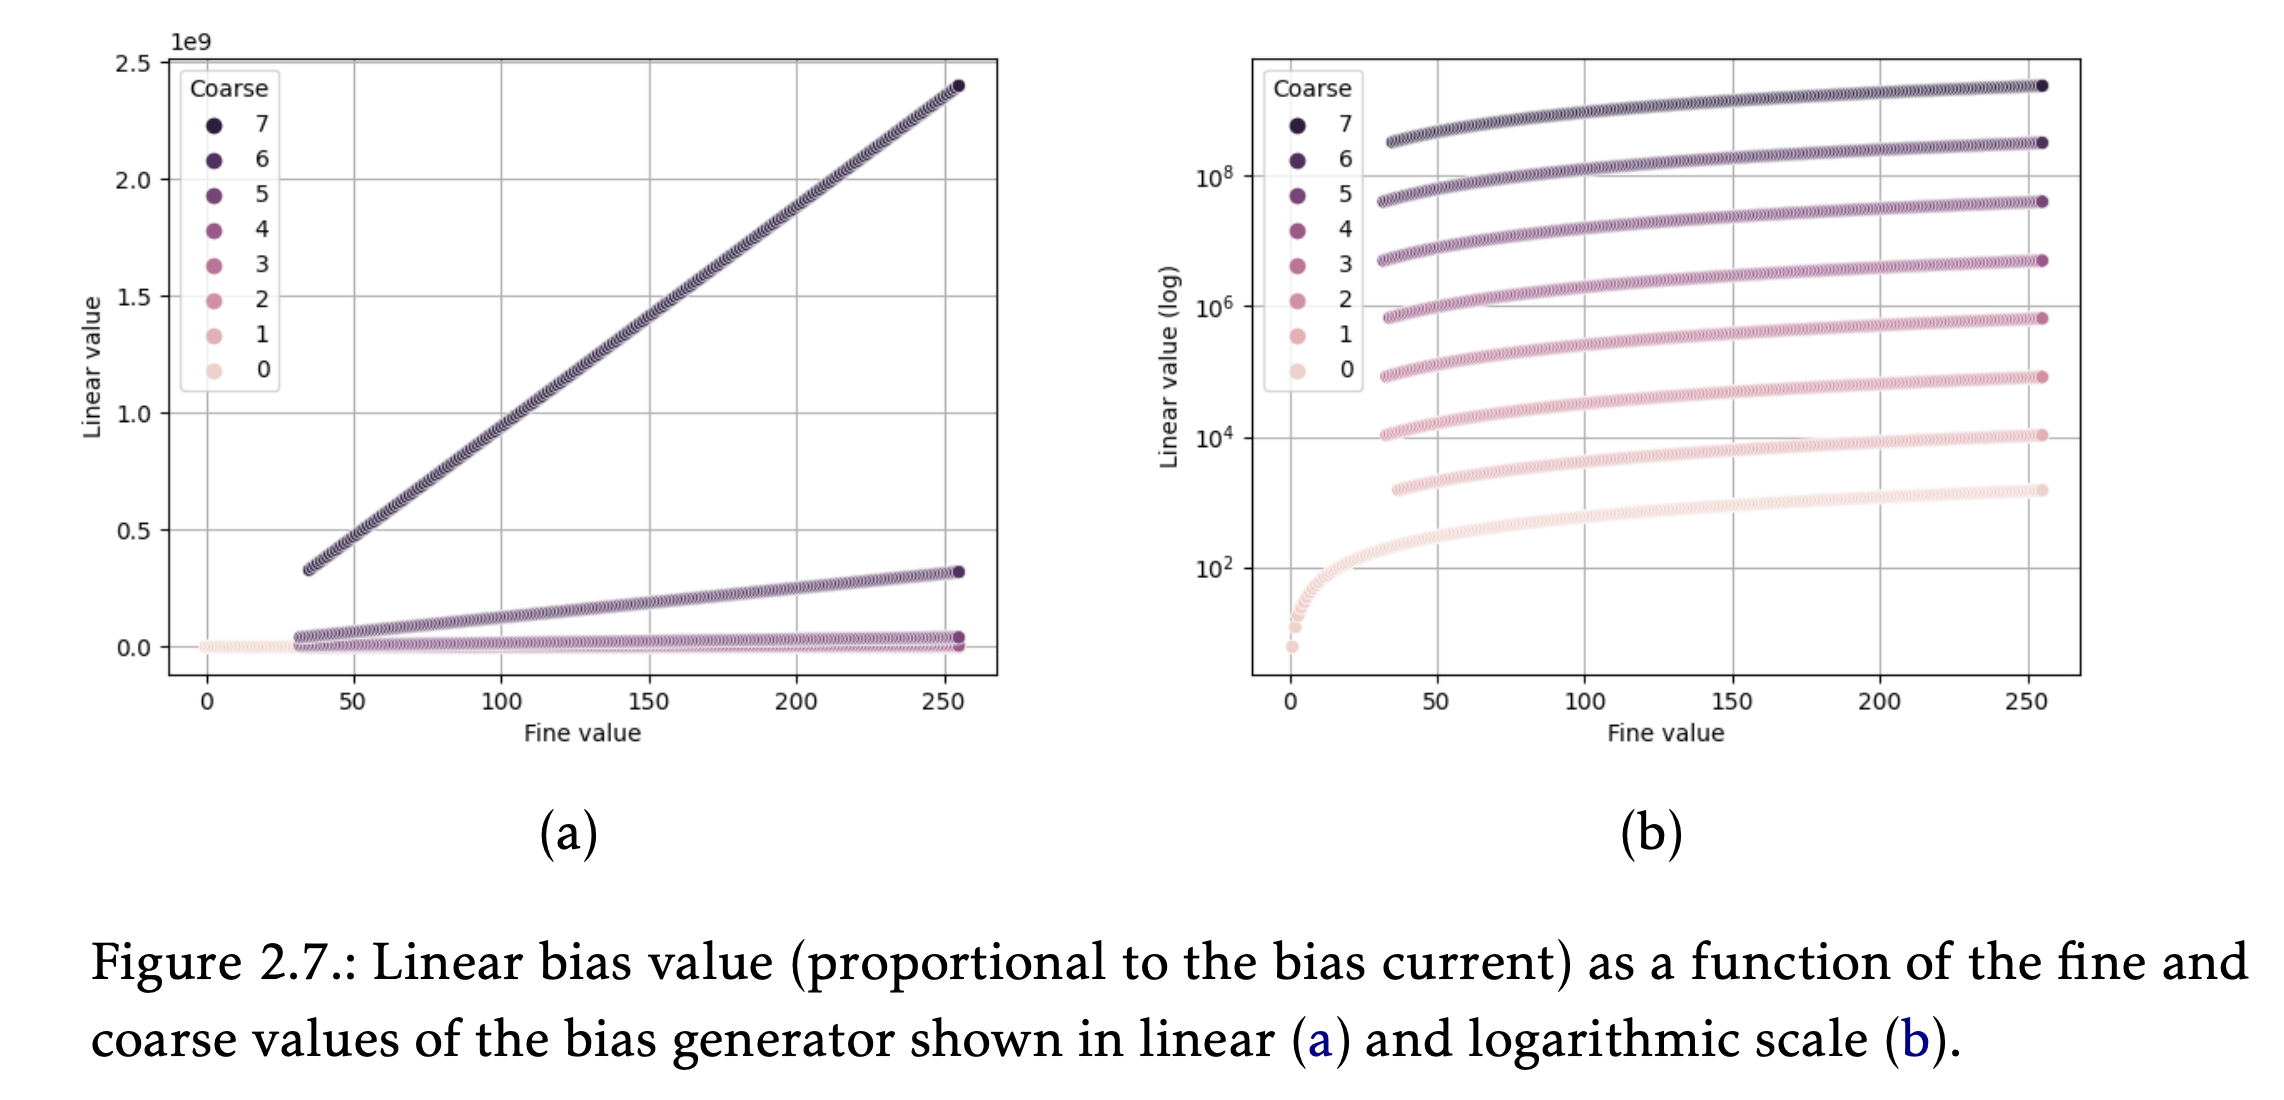

In [9]:
Image("lab5/params_coarse_fine.png")

# New poulation 

In [10]:
# 4 Channels definieren
channels = {
    0: list(range(0, 16)),
    1: list(range(16, 32)),
    2: list(range(32, 48)),
    3: list(range(48, 64))
}


param_group = config1.chips[0].cores[0].parameter_group 

In [11]:
 
import os 


T        = 1.0          # total duration (s)
RATE     = 32           # spikes per second (deterministic, linspace)
N_SPIKES = int(T * RATE)  # = 32 spikes
 
# Per-channel time shifts (ms) — ch0 is aligned to reference
J_SHIFT_PARAM = [0, 10, 25, 50]   # [ch0, ch1, ch2, ch3]
 
N_CH = 4
error_e= 0.20 ## msec
 
 
#spike generation ─────────────────────────────────────────────────────────────────────────────
# Reference: evenly spaced over [0, T)
t_ref = np.linspace(0, T, N_SPIKES, endpoint=False)
t_ref_shifted = (t_ref + error_e) % T
# Each channel: same grid, shifted by epsilon_k
# Spikes that go past T are wrapped (modulo T) so count stays constant

##j is the shift parameter for matching $\epsilon$ is 
    #the error rate which the shift can have be to still exicte 

t_ch = []
for j_ms in J_SHIFT_PARAM:
    j_shift  = j_ms * 1e-3 
    t_raw  = t_ref + j_shift 
    t_wrap = t_raw % T          # wrap around
    t_ch.append(np.sort(t_wrap))
# ─────────────────────────────────────────────────────────────────────────────
 
# print(f"{t_ch[0]}\n")
# print(f"{t_ch[1]}\n")
# print(t_ch)
###__________ dicts of channels
## sort list with 2 
dict_list = []

for ch_idx, arr in enumerate(t_ch):
    d = {f"ch_{ch_idx}:{i}": val for i, val in enumerate(arr)}
    dict_list.append(d)

# Separate Variablen:
dict_ch0 = dict_list[0]
dict_ch1 = dict_list[1]
dict_ch2 = dict_list[2]
dict_ch3 = dict_list[3]

print(f"dict_ch0:{dict_ch0}")
dict_ch0={key:val+error_e for key,val in dict_ch0.items()}
print(f"shifted by {error_e}")


print(f"{t_ch[0]}")
print(f"d={dict_ch0}")
###__________ dicts of channels

###_______________ combinded dicts + + list lookup
#zip all values togetherto a list and also the order of the keys 
# Alle Dicts zusammenführen
combined = {}
for d in [dict_ch0, dict_ch1, dict_ch2, dict_ch3]:
    combined.update(d)

# Sortiert nach Value aufsteigend
sorted_items = sorted(combined.items(), key=lambda x: x[1])

# Zwei Listen: values zum senden, keys als lookup
values_list = [val for key, val in sorted_items]   # zum senden
keys_list   = [key for key, val in sorted_items]   # lookup: welcher channel/index

print(f"value_list{values_list}")
print(f"key_list{keys_list}")
print(f"\nt_ref{t_ref}")
print(f"\nt_ref_shifted{t_ref_shifted}")
###_______________ combinded dicts + list lookup


len(t_ch[0])

dict_ch0:{'ch_0:0': 0.0, 'ch_0:1': 0.03125, 'ch_0:2': 0.0625, 'ch_0:3': 0.09375, 'ch_0:4': 0.125, 'ch_0:5': 0.15625, 'ch_0:6': 0.1875, 'ch_0:7': 0.21875, 'ch_0:8': 0.25, 'ch_0:9': 0.28125, 'ch_0:10': 0.3125, 'ch_0:11': 0.34375, 'ch_0:12': 0.375, 'ch_0:13': 0.40625, 'ch_0:14': 0.4375, 'ch_0:15': 0.46875, 'ch_0:16': 0.5, 'ch_0:17': 0.53125, 'ch_0:18': 0.5625, 'ch_0:19': 0.59375, 'ch_0:20': 0.625, 'ch_0:21': 0.65625, 'ch_0:22': 0.6875, 'ch_0:23': 0.71875, 'ch_0:24': 0.75, 'ch_0:25': 0.78125, 'ch_0:26': 0.8125, 'ch_0:27': 0.84375, 'ch_0:28': 0.875, 'ch_0:29': 0.90625, 'ch_0:30': 0.9375, 'ch_0:31': 0.96875}
shifted by 0.2
[0.      0.03125 0.0625  0.09375 0.125   0.15625 0.1875  0.21875 0.25
 0.28125 0.3125  0.34375 0.375   0.40625 0.4375  0.46875 0.5     0.53125
 0.5625  0.59375 0.625   0.65625 0.6875  0.71875 0.75    0.78125 0.8125
 0.84375 0.875   0.90625 0.9375  0.96875]
d={'ch_0:0': 0.2, 'ch_0:1': 0.23125, 'ch_0:2': 0.2625, 'ch_0:3': 0.29375, 'ch_0:4': 0.325, 'ch_0:5': 0.35625, 'ch_0:6'

32

In [12]:
## set the shifting of the reference line 
error_e= 0.020 ## msec
 
 
#spike generation ─────────────────────────────────────────────────────────────────────────────
# Reference: evenly spaced over [0, T)
# t_ref = np.linspace(0, T, N_SPIKES, endpoint=False)
t_ref = (t_ref + error_e) % T

# print(type(t_ref_shifted))
# print(type(t_ref))

In [13]:
##############################################################################
# REFERENCE
##############################################################################

t_ref = np.linspace(
    0,
    T,
    N_SPIKES,
    endpoint=False
)

epsilon_ref = 0.020

t_ref = (
    t_ref + epsilon_ref
) % T

##############################################################################
# CHANNELS
##############################################################################

t_ch = []

for j_ms in J_SHIFT_PARAM:

    j_shift = j_ms * 1e-3

    t_raw = t_ref + j_shift

    t_ch.append(
        np.sort(
            t_raw % T
        )
    )


In [14]:
print(t_ref[:5])

for i in range(4):
    print(
        f"ch{i}",
        t_ch[i][:5]
    )

[0.02    0.05125 0.0825  0.11375 0.145  ]
ch0 [0.02    0.05125 0.0825  0.11375 0.145  ]
ch1 [0.03    0.06125 0.0925  0.12375 0.155  ]
ch2 [0.01375 0.045   0.07625 0.1075  0.13875]
ch3 [0.0075  0.03875 0.07    0.10125 0.1325 ]


In [15]:
#test test this is a test
combined["ch_0:12"]

0.575

=== Reference spike times (s) ===
[0.02   0.0512 0.0825 0.1138 0.145  0.1762 0.2075 0.2388 0.27   0.3012
 0.3325 0.3638 0.395  0.4262 0.4575 0.4888 0.52   0.5512 0.5825 0.6138
 0.645  0.6762 0.7075 0.7388 0.77   0.8012 0.8325 0.8638 0.895  0.9262
 0.9575 0.9888]

=== Channel 0  (j_shift = 0 ms) ===
[0.02   0.0512 0.0825 0.1138 0.145  0.1762 0.2075 0.2388 0.27   0.3012
 0.3325 0.3638 0.395  0.4262 0.4575 0.4888 0.52   0.5512 0.5825 0.6138
 0.645  0.6762 0.7075 0.7388 0.77   0.8012 0.8325 0.8638 0.895  0.9262
 0.9575 0.9888]

=== Channel 1  (j_shift = 10 ms) ===
[0.03   0.0613 0.0925 0.1238 0.155  0.1862 0.2175 0.2488 0.28   0.3113
 0.3425 0.3738 0.405  0.4362 0.4675 0.4988 0.53   0.5612 0.5925 0.6238
 0.655  0.6862 0.7175 0.7488 0.78   0.8112 0.8425 0.8738 0.905  0.9362
 0.9675 0.9988]

=== Channel 2  (j_shift = 25 ms) ===
[0.0137 0.045  0.0763 0.1075 0.1388 0.17   0.2012 0.2325 0.2638 0.295
 0.3263 0.3575 0.3888 0.42   0.4512 0.4825 0.5138 0.545  0.5762 0.6075
 0.6388 0.67   0.7012 0.7

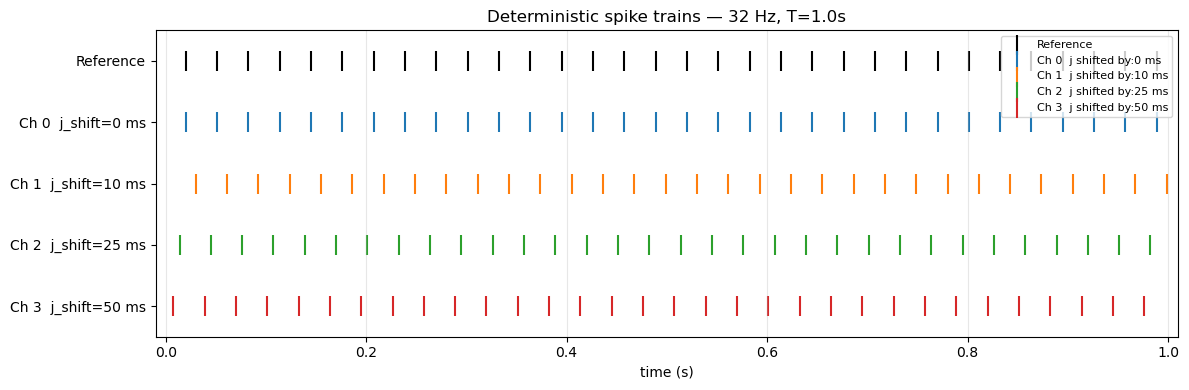


Plot saved to step1_spikes.png


In [16]:
print("=== Reference spike times (s) ===")
print(np.round(t_ref, 4))
 
for ch in range(N_CH):
    print(f"\n=== Channel {ch}  (j_shift = {J_SHIFT_PARAM[ch]} ms) ===")
    print(np.round(t_ch[ch], 4))
 
# ─────────────────────────────────────────────────────────────────────────────
# RASTER PLOT
# ─────────────────────────────────────────────────────────────────────────────
 
fig, ax = plt.subplots(figsize=(12, 4))
 
# y-positions: reference at top (row N_CH), channels below (N_CH-1 down to 0)
COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
 
# Reference
y_ref = N_CH
ax.scatter(t_ref, np.full_like(t_ref, y_ref),
           marker='|', s=200, linewidths=1.5, color='black', label='Reference')
 
# Channels
for ch in range(N_CH):
    y = N_CH - 1 - ch
    ax.scatter(t_ch[ch], np.full_like(t_ch[ch], y),
               marker='|', s=200, linewidths=1.5,
               color=COLORS[ch], label=f'Ch {ch}  j shifted by:{J_SHIFT_PARAM[ch]} ms')
 
# Formatting
ax.set_yticks(range(N_CH + 1))
ax.set_yticklabels(
    [f'Ch {N_CH-1-i}  j_shift={J_SHIFT_PARAM[N_CH-1-i]} ms' for i in range(N_CH)] + ['Reference']
)
ax.set_xlabel('time (s)')
ax.set_title(f'Deterministic spike trains — {RATE} Hz, T={T}s')
ax.set_xlim(-0.01, T + 0.01)
ax.set_ylim(-0.5, N_CH + 0.5)
ax.legend(loc='upper right', fontsize=8)
ax.grid(axis='x', alpha=0.3)
 
plt.tight_layout()
files_found= sys


plot_number_in_dir = len([name for name in os.listdir('./keyspot_plots') if os.path.isfile(os.path.join('./keyspot_plots', name))])
print(plot_number_in_dir)
plt.savefig(f'keyspot_plots/step1_spikes{plot_number_in_dir}.png', dpi=150)



plt.show()
print("\nPlot saved to step1_spikes.png")

In [17]:
!pwd 

/home/dyuser-a/keyspotting/dynap-se1


In [18]:
!ls -a 

 .				       network_primitives
 ..				       parameters
 board_registry			       params.py
 details			       __pycache__
 doc				       pygetscope
 .DS_Store			       pyspcmscope
 dynapse1constants.py		       Readme.md
 dynapse1utils.py		       register.sh
 dynapse-biases-howtosetup.md	       requirements.38.txt
 example			       samna_info.json
 .gitignore			       samna.log
 .gitlab-ci.yml			       stdp_algorithms
 .gitmodules			       stdp.py
 .ipynb_checkpoints		       stdp_utils.py
 jupyterlab-experiments		       step1_spikes.png
 keyspot_plots			       step3_wta_result.png
'keyspot_plots\step3_wta_result.png'   test
 lab5				       tools
 Lab5_P1_p.ipynb		       tutorials
 live_gui			       venv_samna
 netgen.py			       wta_4ch_result.png


# GLOBAL SETUP:
### for all params 

In [19]:

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS (from samna / FPGA limits)
# ─────────────────────────────────────────────────────────────────────────────
MAX_ISI      = 2**24        # hardware limit
MAX_FPGA_LEN = 2**16        # max number of events in one preload

# ─────────────────────────────────────────────────────────────────────────────
# PARAMETERS
# ─────────────────────────────────────────────────────────────────────────────
T             = 1.0               # duration (s)
RATE          = 32                # spikes/s
N_SPIKES      = int(T * RATE)     # = 32
J_SHIFT_PARAM = [0, 10, 25, 50]  # per-channel shift [ms]  → j in your notation
N_CH          = 4
TARGET_CHIP   = 0                 # all on chip 0
ISI_BASE      = 900               # FPGA time unit: 900/90 = 10 µs per tick

# Spikegen neuron IDs on chip=0, core=1
# neuron 0 is reserved → use 1,2,3,4 for ch0,ch1,ch2,ch3
SPIKEGEN_NEURON = {ch: ch + 1 for ch in range(N_CH)}   # {0:1, 1:2, 2:3, 3:4}

# ─────────────────────────────────────────────────────────────────────────────
# SPIKE GENERATION
# ─────────────────────────────────────────────────────────────────────────────
t_ref = np.linspace(0, T, N_SPIKES, endpoint=False)

t_ch = []
for j_ms in J_SHIFT_PARAM:
    j_shift = j_ms * 1e-3
    t_raw   = t_ref + j_shift
    t_wrap  = t_raw % T          # wrap — keeps N_SPIKES constant per channel
    t_ch.append(np.sort(t_wrap))


In [20]:
##############################################################################
# STEP 3 — COINCIDENCE MATCHING + WTA NETWORK
#
# Goal
# ----
# Detect which input channel best matches the reference spike train.
#
# Expected Result
# ---------------
# Channel 0 should win because:
#
#     ch0 shift = 0 ms
#
# while
#
#     ch1 shift = 10 ms
#     ch2 shift = 25 ms
#     ch3 shift = 50 ms
#
# Architecture
# ------------
#
#                    Reference SpikeGen
#                           |
#          +----------------+----------------+
#          |                |                |
#          v                v                v
#
#       Match_0         Match_1         Match_2         Match_3
#          |                |                |               |
#          v                v                v               v
#
#        Inh_0          Inh_1          Inh_2          Inh_3
#          |                |                |               |
#          +----------------+----------------+---------------+
#
#                           WTA
#
# Inhibition
# ----------
#
#     Inh_k  --GABA_B-->  Match_j
#
# for all
#
#     j != k
#
# The strongest matching population should suppress all competitors.
#
##############################################################################

##############################################################################
# NETWORK SIZE
##############################################################################

N_CH = 4

MATCH_CH = 16
INH_CH   = 4

##############################################################################
# SPIKEGEN LAYOUT
#
# Core 1
#
#   neuron 1 : Input Channel 0
#   neuron 2 : Input Channel 1
#   neuron 3 : Input Channel 2
#   neuron 4 : Input Channel 3
#   neuron 5 : Reference Spike Train
#
##############################################################################

REFERENCE_NRN = 5

spikegens = [
    Neuron(0, 1, ch + 1, True)
    for ch in range(N_CH)
]

reference_sg = Neuron(
    0,
    1,
    REFERENCE_NRN,
    True
)

##############################################################################
# MATCH POPULATIONS
#
# Core 0
#
# Match_0 : neurons  1 - 16
# Match_1 : neurons 17 - 32
# Match_2 : neurons 33 - 48
# Match_3 : neurons 49 - 64
#
##############################################################################

match_pop = []

for ch in range(N_CH):

    start = 1 + ch * MATCH_CH

    match_pop.append(
        [
            Neuron(0, 0, start + i)
            for i in range(MATCH_CH)
        ]
    )

##############################################################################
# INHIBITORY POPULATIONS
#
# Core 0
#
# Inh_0 : neurons 65 - 68
# Inh_1 : neurons 69 - 72
# Inh_2 : neurons 73 - 76
# Inh_3 : neurons 77 - 80
#
##############################################################################

INH_START = 65

inh_pop = []

for ch in range(N_CH):

    start = INH_START + ch * INH_CH

    inh_pop.append(
        [
            Neuron(0, 0, start + i)
            for i in range(INH_CH)
        ]
    )

##############################################################################
# MONITORED NEURONS
##############################################################################

MATCH_IDS = []

for ch in range(N_CH):

    start = 1 + ch * MATCH_CH

    for i in range(MATCH_CH):

        MATCH_IDS.append(
            (
                0,
                0,
                start + i
            )
        )

INH_IDS = []

for ch in range(N_CH):

    start = INH_START + ch * INH_CH

    for i in range(INH_CH):

        INH_IDS.append(
            (
                0,
                0,
                start + i
            )
        )

##############################################################################
# NETWORK GENERATOR
##############################################################################

net_gen = NetworkGenerator()
net_gen.clear_network()

##############################################################################
# INPUT CHANNEL -> MATCH POPULATION
#
# Every input channel drives only its own matching population.
#
# Input_0 -> Match_0
# Input_1 -> Match_1
# Input_2 -> Match_2
# Input_3 -> Match_3
#
##############################################################################

for ch in range(N_CH):

    sg = spikegens[ch]

    for m in match_pop[ch]:

        net_gen.add_connection(
            sg,
            m,
            dyn1.Dynapse1SynType.AMPA
        )

##############################################################################
# REFERENCE -> ALL MATCH POPULATIONS
#
# Every matching population receives the same reference pattern.
#
# Reference -> Match_0
# Reference -> Match_1
# Reference -> Match_2
# Reference -> Match_3
#
##############################################################################

for ch in range(N_CH):

    for m in match_pop[ch]:

        net_gen.add_connection(
            reference_sg,
            m,
            dyn1.Dynapse1SynType.AMPA
        )

##############################################################################
# MATCH -> LOCAL INHIBITION
#
# Strong matching activity should activate the local inhibitory population.
#
# Match_k -> Inh_k
#
##############################################################################

for ch in range(N_CH):

    for m in match_pop[ch]:

        for inh in inh_pop[ch]:

            net_gen.add_connection(
                m,
                inh,
                dyn1.Dynapse1SynType.AMPA
            )

##############################################################################
# WINNER TAKES ALL
#
# Inh_k suppresses every competing Match population.
#
# Example:
#
#   Inh_0 --| Match_1
#   Inh_0 --| Match_2
#   Inh_0 --| Match_3
#
##############################################################################

for source_ch in range(N_CH):

    for target_ch in range(N_CH):

        if source_ch == target_ch:
            continue

        for inh in inh_pop[source_ch]:

            for m in match_pop[target_ch]:

                net_gen.add_connection(
                    inh,
                    m,
                    dyn1.Dynapse1SynType.GABA_B
                )

##############################################################################
# OPTIONAL INHIBITORY STABILIZATION
#
# Can be disabled during early debugging.
#
# Inh_k --GABA_A--> Inh_k
#
##############################################################################

ENABLE_LOCAL_INH = True

if ENABLE_LOCAL_INH:

    for ch in range(N_CH):

        for inh_a in inh_pop[ch]:

            for inh_b in inh_pop[ch]:

                if inh_a is inh_b:
                    continue

                net_gen.add_connection(
                    inh_a,
                    inh_b,
                    dyn1.Dynapse1SynType.GABA_A
                )

##############################################################################
# BUILD CONFIGURATION
##############################################################################

new_config = net_gen.make_dynapse1_configuration()

model.apply_configuration(
    new_config
)

print("Coincidence matching network loaded.")

##############################################################################
# FPGA EVENT MAPPING
#
# Assumes the earlier spike-generation code created:
#
#     t_ref
#     values_list
#     keys_list
#
# Add reference spikes to the event stream.
#
##############################################################################

reference_dict = {
    f"ref:{i}": t
    for i, t in enumerate(t_ref)
}

combined.update(reference_dict)

##############################################################################
# REBUILD SORTED EVENT LIST
##############################################################################

sorted_items = sorted(
    combined.items(),
    key=lambda x: x[1]
)

values_list = [
    val
    for key, val in sorted_items
]

keys_list = [
    key
    for key, val in sorted_items
]

##############################################################################
# EVENT -> SPIKEGEN LOOKUP
#
# Input channels:
#
#   ch_0 -> neuron 1
#   ch_1 -> neuron 2
#   ch_2 -> neuron 3
#   ch_3 -> neuron 4
#
# Reference:
#
#   ref -> neuron 5
#
##############################################################################

def key_to_nrn(key):

    if key.startswith("ref"):
        return REFERENCE_NRN

    ch = int(
        key.split(":")[0]
           .split("_")[1]
    )

    return ch + 1

indices = [
    key_to_nrn(k)
    for k in keys_list
]

target_chips = [
    TARGET_CHIP
] * len(values_list)

##############################################################################
# FPGA PROGRAMMING
##############################################################################

from dynapse1utils import set_fpga_spike_gen

fpga_spike_gen = model.get_fpga_spike_gen()

set_fpga_spike_gen(
    fpga_spike_gen,
    values_list,
    indices,
    target_chips,
    ISI_BASE,
    repeat_mode=True
)

print("FPGA pattern loaded.")

##############################################################################
# MONITORING SETUP
##############################################################################

monitored = MATCH_IDS + INH_IDS

graph, filter_node, sink_node = ut.create_neuron_select_graph(
    model,
    monitored
)

##############################################################################
# RUN EXPERIMENT
##############################################################################

set_params(
    model,
    param_group=param_group
)

D_stim = 3.0
D_post = 2.0

graph.start()

filter_node.set_neurons(
    monitored
)

sink_node.get_events()

api.reset_timestamp()

fpga_spike_gen.start()

time.sleep(D_stim)

fpga_spike_gen.stop()

time.sleep(D_post)

graph.stop()

events = sink_node.get_events()

print(f"{len(events)} events recorded.")

Coincidence matching network loaded.New configuration applied to DYNAP-SE1!

FPGA pattern loaded.
1416 events recorded.


([<matplotlib.axis.YTick at 0x78f0222c1220>,
 [Text(0, 1, 'Input0'),
  Text(0, 2, 'Input1'),
  Text(0, 3, 'Input2'),
  Text(0, 4, 'Input3'),
  Text(0, 5, 'Reference')])

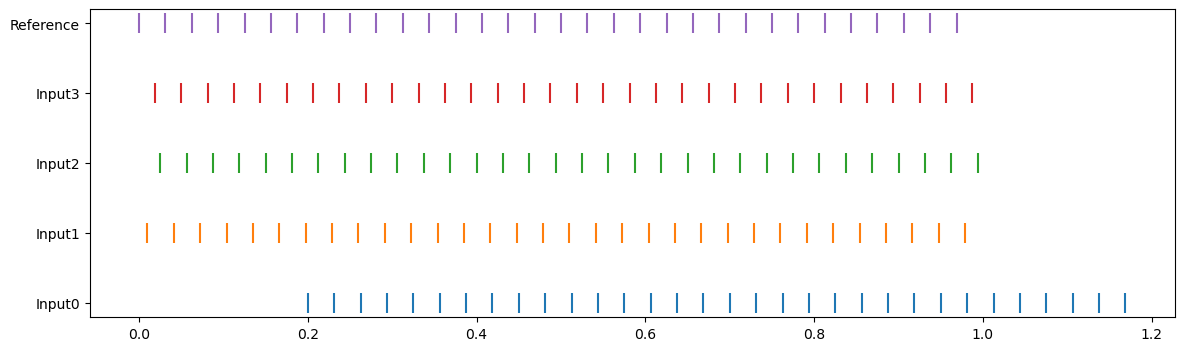

In [21]:
plt.figure(figsize=(14,4))

for sg in range(1,6):

    mask = np.array(indices) == sg

    plt.scatter(
        np.array(values_list)[mask],
        np.full(mask.sum(), sg),
        marker="|",
        s=200
    )

plt.yticks(
    [1,2,3,4,5],
    [
        "Input0",
        "Input1",
        "Input2",
        "Input3",
        "Reference"
    ]
)

In [22]:

# score_match = []

# for ch in range(N_CH):

#     score_match.append(
#         np.trapz(
#             match_rate[ch],
#             t_axis
#         )
#     )
# winner = np.argmax(score_match)




# plt.figure(figsize=(8,4))

# plt.bar(
#     range(N_CH),
#     score_match
# )

# plt.xticks(
#     range(N_CH),
#     [
#         "0 ms",
#         "10 ms",
#         "25 ms",
#         "50 ms"
#     ]
# )

# plt.ylabel("Integrated activity")
# plt.xlabel("Temporal shift")


In [23]:
# plt.figure(figsize=(8,4))

# plt.bar(
#     range(N_CH),
#     score_match
# )

# plt.xticks(
#     range(N_CH),
#     [
#         "0 ms",
#         "10 ms",
#         "25 ms",
#         "50 ms"
#     ]
# )

# plt.ylabel("Integrated activity")
# plt.xlabel("Temporal shift")



WTA RESULT
Channel 0: Match Score = 0.00
Channel 1: Match Score = 0.00
Channel 2: Match Score = 0.00
Channel 3: Match Score = 0.00

Winner = Channel 0


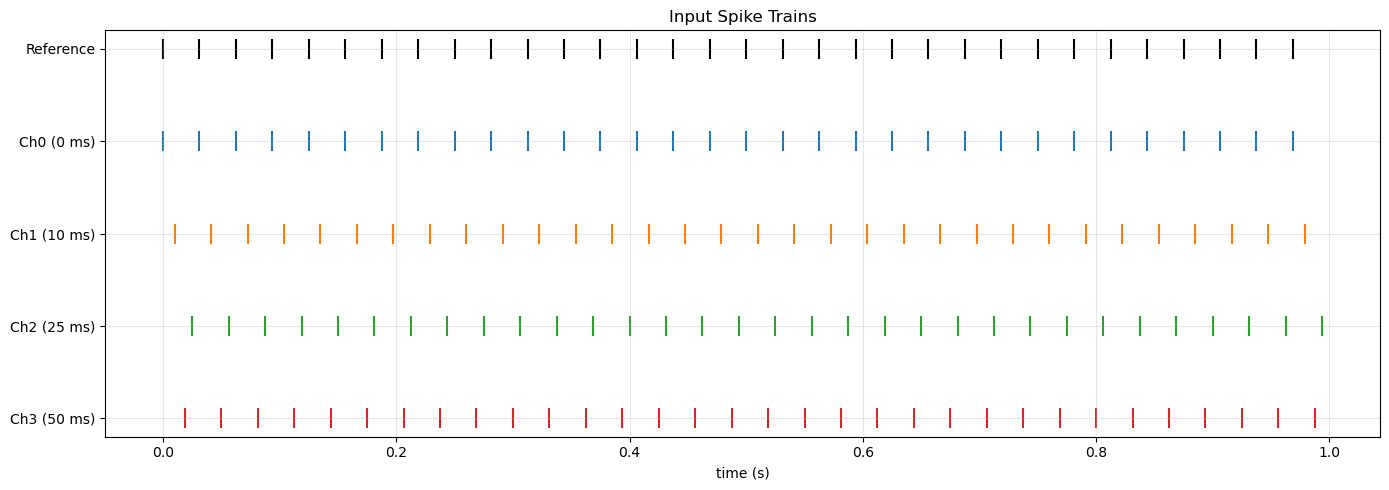

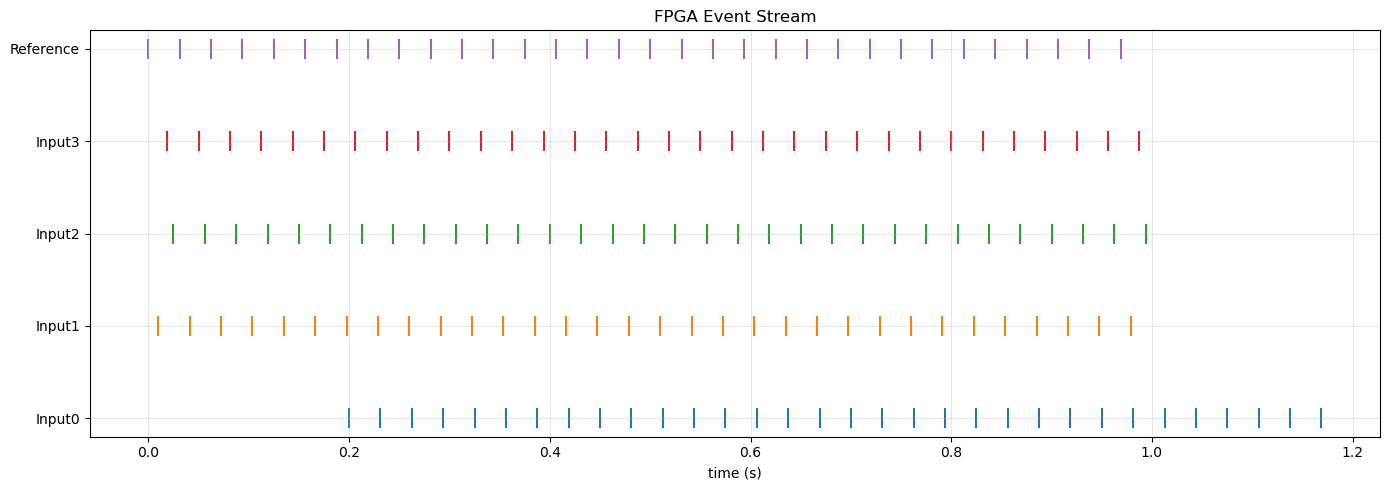

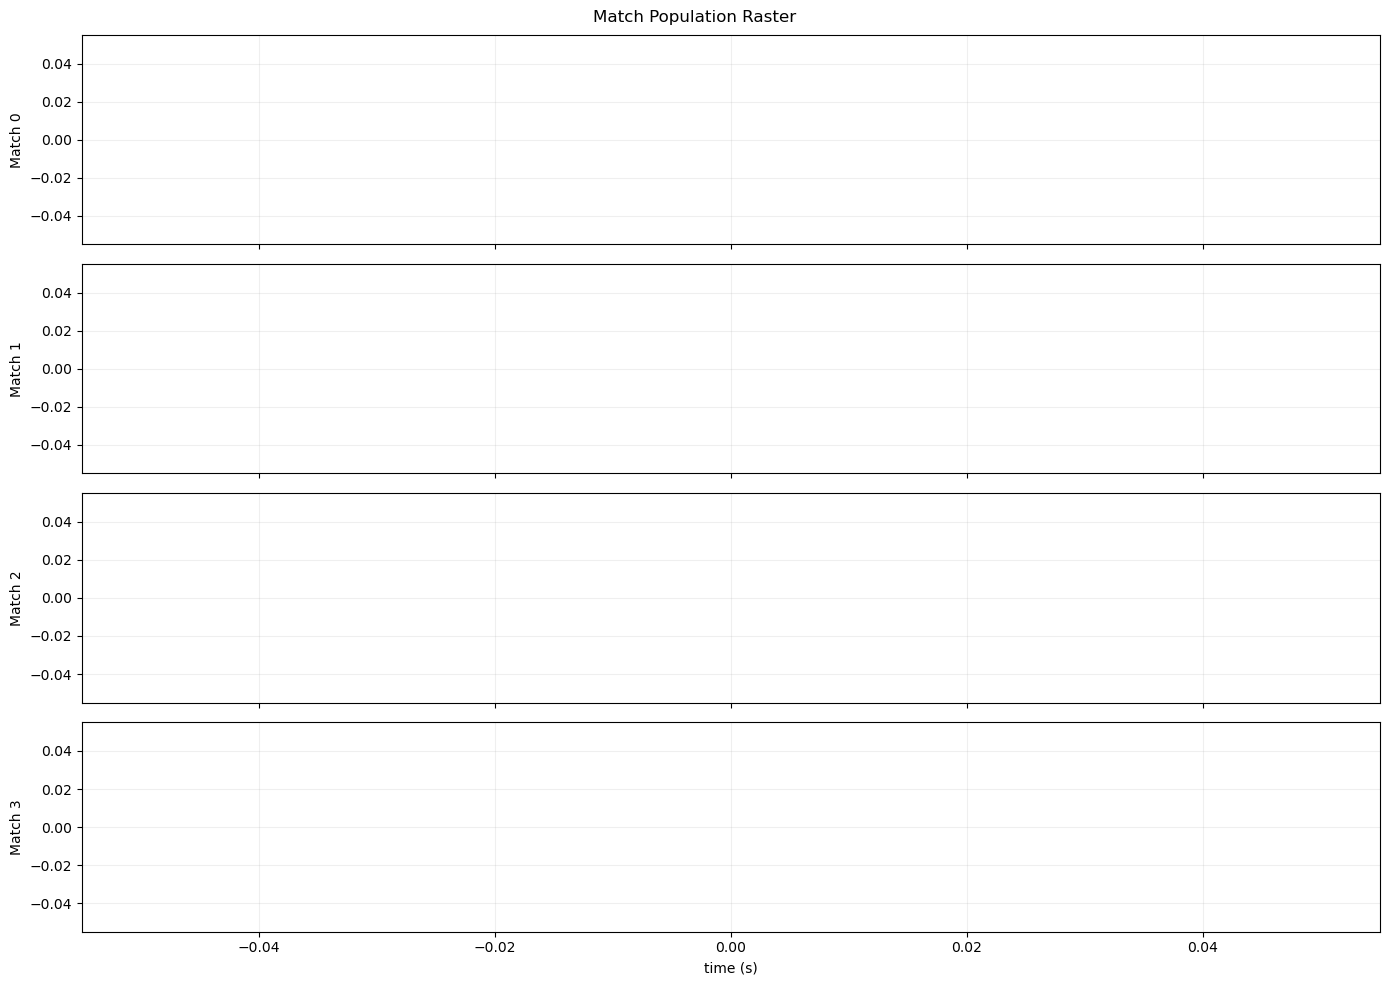

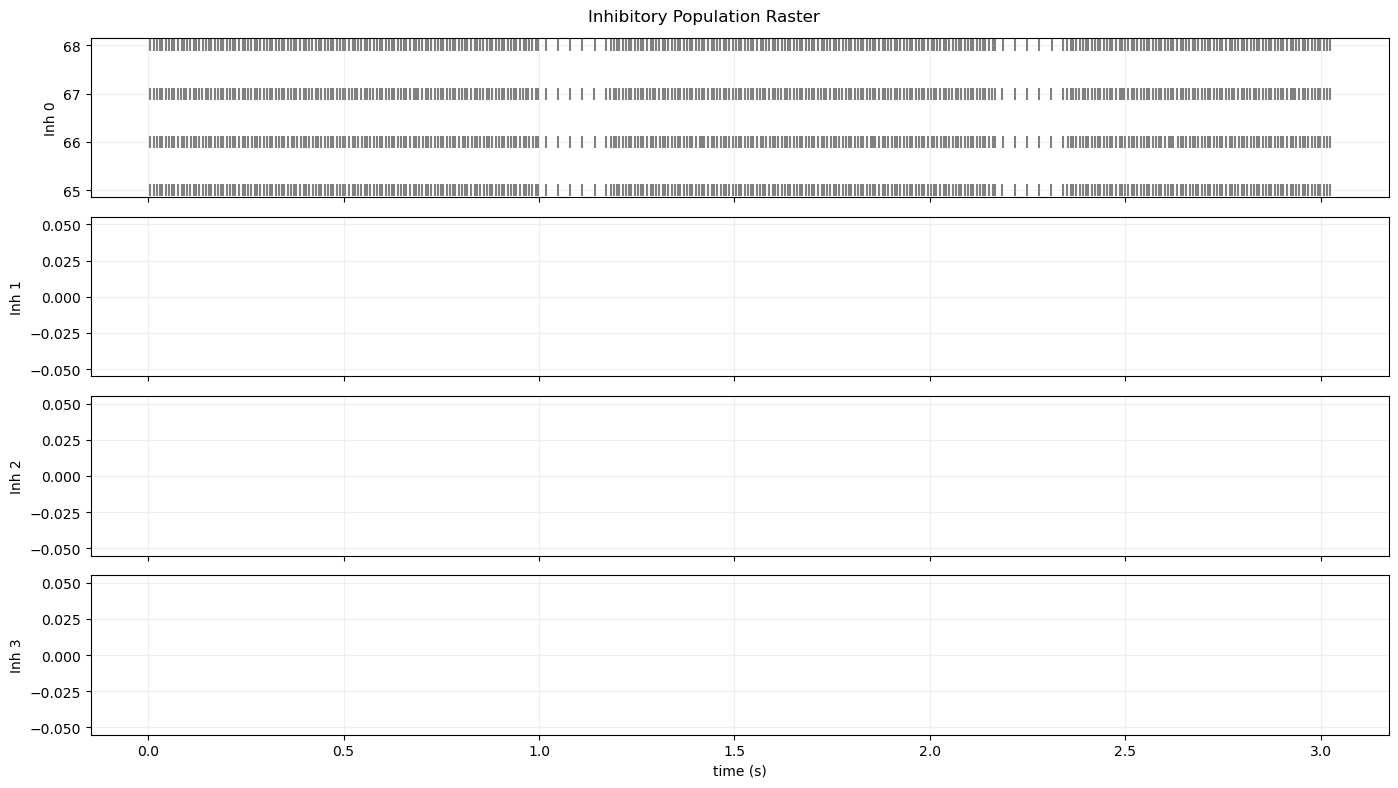

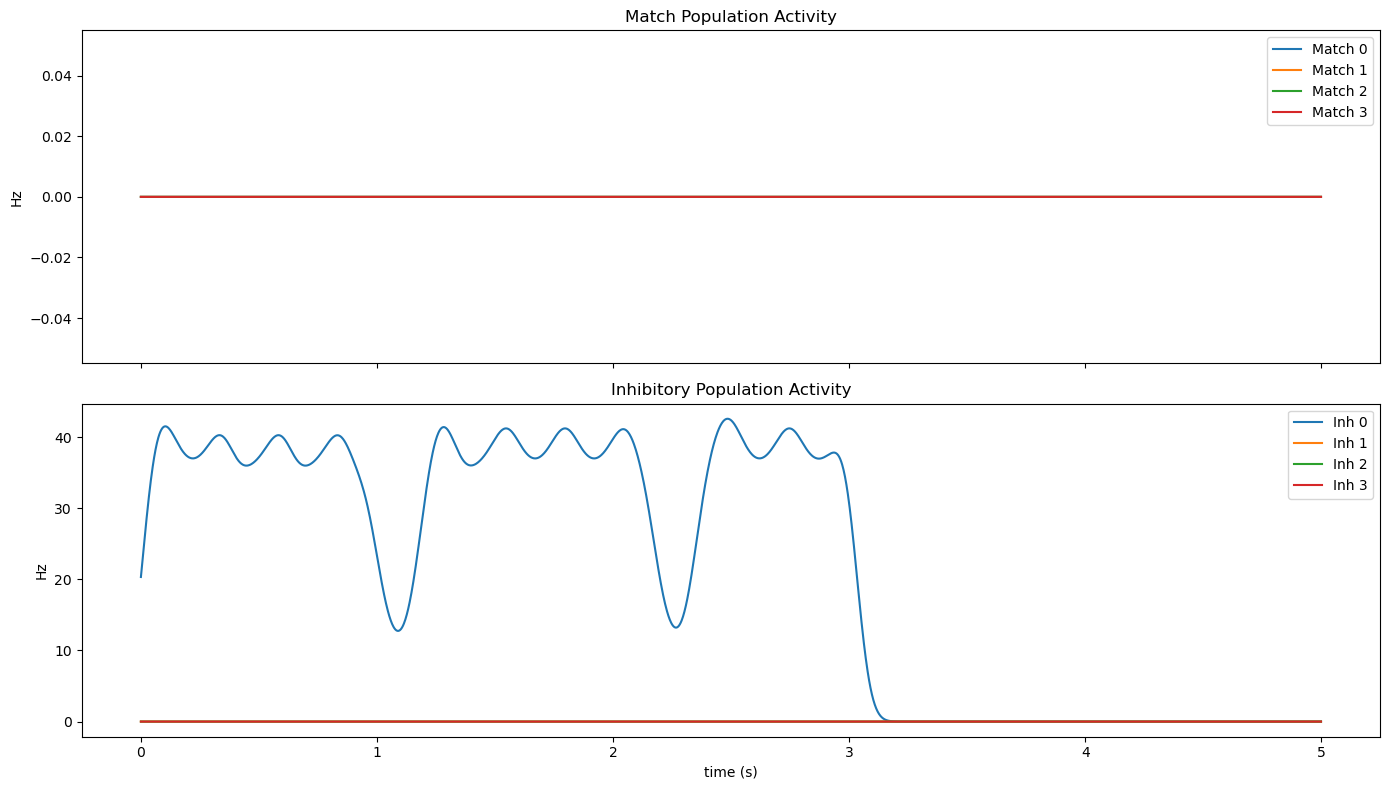

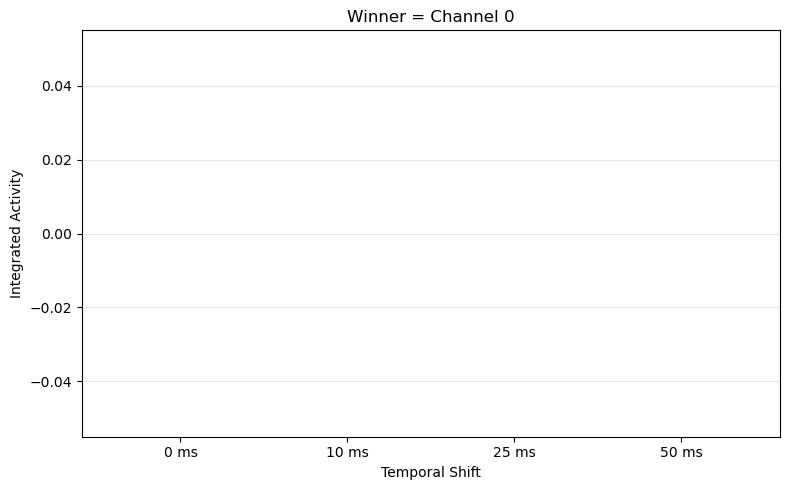

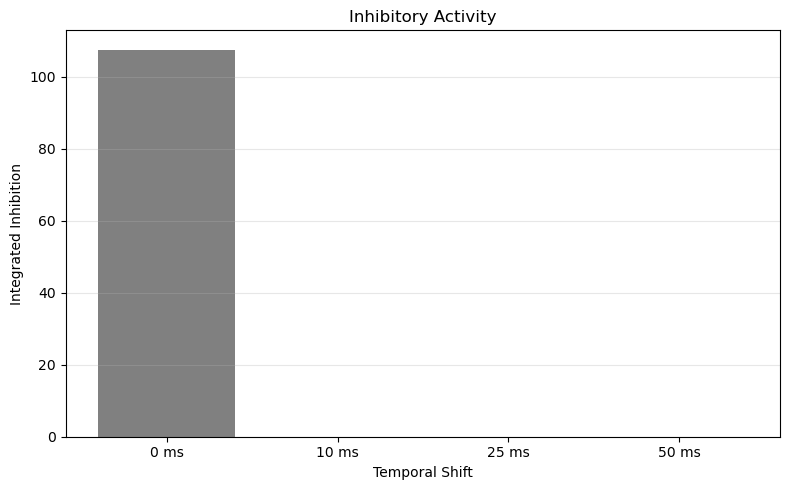


SUMMARY
Ch0 | Match=    0.00 | Inh=  107.47
Ch1 | Match=    0.00 | Inh=    0.00
Ch2 | Match=    0.00 | Inh=    0.00
Ch3 | Match=    0.00 | Inh=    0.00

Detected Winner: Channel 0


In [24]:
##############################################################################
# STEP 4 — ANALYSIS AND VISUALIZATION
#
# Goal
# ----
# Verify the complete processing chain:
#
#   Synthetic spike generation
#          ↓
#   FPGA event stream
#          ↓
#   Match populations
#          ↓
#   Inhibitory populations
#          ↓
#   Winner-Takes-All decision
#
# We already know the expected outcome:
#
#   Channel 0 (0 ms shift) should win
#
# because it is perfectly aligned with the reference pattern.
#
##############################################################################

##############################################################################
# EXTRACT RECORDED EVENTS
##############################################################################

spike_t = np.array([
    e.timestamp * 1e-6
    for e in events
])

spike_core = np.array([
    e.core_id
    for e in events
])

spike_nrn = np.array([
    e.neuron_id
    for e in events
])

D = D_stim + D_post

##############################################################################
# MATCH POPULATION LOOKUP
#
# Match_0 : neurons  1 - 16
# Match_1 : neurons 17 - 32
# Match_2 : neurons 33 - 48
# Match_3 : neurons 49 - 64
#
##############################################################################

def get_match_spikes(ch):

    lo = 1 + ch * MATCH_CH
    hi = lo + MATCH_CH

    mask = (
        (spike_core == 0)
        &
        (spike_nrn >= lo)
        &
        (spike_nrn < hi)
    )

    return spike_t[mask], spike_nrn[mask]

##############################################################################
# INHIBITORY POPULATION LOOKUP
#
# Inh_0 : neurons 65 - 68
# Inh_1 : neurons 69 - 72
# Inh_2 : neurons 73 - 76
# Inh_3 : neurons 77 - 80
#
##############################################################################

def get_inh_spikes(ch):

    lo = INH_START + ch * INH_CH
    hi = lo + INH_CH

    mask = (
        (spike_core == 0)
        &
        (spike_nrn >= lo)
        &
        (spike_nrn < hi)
    )

    return spike_t[mask], spike_nrn[mask]

##############################################################################
# POPULATION FIRING RATE
#
# Gaussian smoothing converts sparse spikes into a continuous rate estimate.
#
##############################################################################

fs = 500

bins = int(D * fs)

t_axis = np.arange(bins) / fs

sigma = 0.05

x_kernel = (
    np.arange(
        int(-0.5 * fs),
        int(0.5 * fs)
    ) / fs
)

gauss = np.exp(
    -x_kernel**2 /
    (2 * sigma**2)
)

gauss /= gauss.sum()

##############################################################################
# RATE ESTIMATOR
##############################################################################

def population_rate(times, n_neurons):

    b = np.zeros(bins)

    idx = (times * fs).astype(int)

    idx = idx[
        (idx >= 0)
        &
        (idx < bins)
    ]

    b[idx] = 1

    return (
        np.convolve(
            b,
            gauss,
            mode="same"
        )
        * fs
        / n_neurons
    )

##############################################################################
# COMPUTE MATCH AND INHIBITORY RATES
##############################################################################

match_rates = []
inh_rates = []

for ch in range(N_CH):

    match_times, _ = get_match_spikes(ch)
    inh_times, _ = get_inh_spikes(ch)

    match_rates.append(
        population_rate(
            match_times,
            MATCH_CH
        )
    )

    inh_rates.append(
        population_rate(
            inh_times,
            INH_CH
        )
    )

##############################################################################
# ACTIVITY SCORE
#
# Integrated activity of each matching population.
#
# This becomes the WTA decision variable.
#
##############################################################################

match_scores = []

for ch in range(N_CH):

    score = np.trapz(
        match_rates[ch],
        t_axis
    )

    match_scores.append(score)

match_scores = np.array(match_scores)

##############################################################################
# INHIBITORY SCORE
##############################################################################

inh_scores = []

for ch in range(N_CH):

    score = np.trapz(
        inh_rates[ch],
        t_axis
    )

    inh_scores.append(score)

inh_scores = np.array(inh_scores)

##############################################################################
# WINNER DETECTION
##############################################################################

winner = np.argmax(match_scores)

print("\n==============================")
print("WTA RESULT")
print("==============================")

for ch in range(N_CH):

    print(
        f"Channel {ch}: "
        f"Match Score = {match_scores[ch]:.2f}"
    )

print(f"\nWinner = Channel {winner}")

##############################################################################
# PLOT 1
#
# INPUT VERIFICATION
#
# Confirms that the generated spike trains contain the expected temporal
# offsets before anything is sent to the hardware.
#
##############################################################################

fig, ax = plt.subplots(
    figsize=(14,5)
)

COLORS = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red"
]

ax.scatter(
    t_ref,
    np.full_like(t_ref, N_CH),
    marker="|",
    s=200,
    color="black",
    label="Reference"
)

for ch in range(N_CH):

    ax.scatter(
        t_ch[ch],
        np.full_like(
            t_ch[ch],
            N_CH - 1 - ch
        ),
        marker="|",
        s=200,
        color=COLORS[ch],
        label=f"Ch {ch}"
    )

ax.set_yticks(
    [0,1,2,3,4]
)

ax.set_yticklabels(
    [
        "Ch3 (50 ms)",
        "Ch2 (25 ms)",
        "Ch1 (10 ms)",
        "Ch0 (0 ms)",
        "Reference"
    ]
)

ax.set_xlabel("time (s)")
ax.set_title("Input Spike Trains")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

##############################################################################
# PLOT 2
#
# FPGA EVENT STREAM
#
# Verifies exactly what was sent to the FPGA.
#
##############################################################################

fig, ax = plt.subplots(
    figsize=(14,5)
)

indices_np = np.array(indices)
values_np = np.array(values_list)

labels = {
    1: "Input0",
    2: "Input1",
    3: "Input2",
    4: "Input3",
    5: "Reference"
}

for sg in range(1,6):

    mask = indices_np == sg

    ax.scatter(
        values_np[mask],
        np.full(mask.sum(), sg),
        marker="|",
        s=200
    )

ax.set_yticks(
    [1,2,3,4,5]
)

ax.set_yticklabels(
    [
        labels[i]
        for i in [1,2,3,4,5]
    ]
)

ax.set_xlabel("time (s)")
ax.set_title("FPGA Event Stream")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

##############################################################################
# PLOT 3
#
# MATCH POPULATION RASTER
#
# Shows which matching population becomes active.
#
##############################################################################

fig, axes = plt.subplots(
    N_CH,
    1,
    figsize=(14,10),
    sharex=True
)

for ch in range(N_CH):

    t_match, n_match = get_match_spikes(ch)

    axes[ch].scatter(
        t_match,
        n_match,
        marker="|",
        s=80,
        color=COLORS[ch]
    )

    axes[ch].set_ylabel(
        f"Match {ch}"
    )

    axes[ch].grid(alpha=0.2)

axes[-1].set_xlabel(
    "time (s)"
)

fig.suptitle(
    "Match Population Raster"
)

plt.tight_layout()
plt.show()

##############################################################################
# PLOT 4
#
# INHIBITORY POPULATION RASTER
#
# Shows how strongly each channel recruits inhibition.
#
##############################################################################

fig, axes = plt.subplots(
    N_CH,
    1,
    figsize=(14,8),
    sharex=True
)

for ch in range(N_CH):

    t_inh, n_inh = get_inh_spikes(ch)

    axes[ch].scatter(
        t_inh,
        n_inh,
        marker="|",
        s=80,
        color="gray"
    )

    axes[ch].set_ylabel(
        f"Inh {ch}"
    )

    axes[ch].grid(alpha=0.2)

axes[-1].set_xlabel(
    "time (s)"
)

fig.suptitle(
    "Inhibitory Population Raster"
)

plt.tight_layout()
plt.show()

##############################################################################
# PLOT 5
#
# POPULATION FIRING RATES
#
# Continuous activity estimate for all channels.
#
##############################################################################

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14,8),
    sharex=True
)

for ch in range(N_CH):

    axes[0].plot(
        t_axis,
        match_rates[ch],
        color=COLORS[ch],
        label=f"Match {ch}"
    )

axes[0].set_ylabel("Hz")
axes[0].set_title("Match Population Activity")
axes[0].legend()

for ch in range(N_CH):

    axes[1].plot(
        t_axis,
        inh_rates[ch],
        label=f"Inh {ch}"
    )

axes[1].set_ylabel("Hz")
axes[1].set_xlabel("time (s)")
axes[1].set_title("Inhibitory Population Activity")
axes[1].legend()

plt.tight_layout()
plt.show()

##############################################################################
# PLOT 6
#
# MATCH SCORE
#
# Integrated activity over the complete experiment.
#
# This is the final WTA decision metric.
#
##############################################################################

plt.figure(
    figsize=(8,5)
)

plt.bar(
    range(N_CH),
    match_scores,
    color=COLORS
)

plt.xticks(
    range(N_CH),
    [
        "0 ms",
        "10 ms",
        "25 ms",
        "50 ms"
    ]
)

plt.ylabel(
    "Integrated Activity"
)

plt.xlabel(
    "Temporal Shift"
)

plt.title(
    f"Winner = Channel {winner}"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

##############################################################################
# PLOT 7
#
# INHIBITORY SCORE
#
# Measures how strongly each channel suppresses competitors.
#
##############################################################################

plt.figure(
    figsize=(8,5)
)

plt.bar(
    range(N_CH),
    inh_scores,
    color="gray"
)

plt.xticks(
    range(N_CH),
    [
        "0 ms",
        "10 ms",
        "25 ms",
        "50 ms"
    ]
)

plt.ylabel(
    "Integrated Inhibition"
)

plt.xlabel(
    "Temporal Shift"
)

plt.title(
    "Inhibitory Activity"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

##############################################################################
# SUMMARY
##############################################################################

print("\n==============================")
print("SUMMARY")
print("==============================")

for ch in range(N_CH):

    print(
        f"Ch{ch} | "
        f"Match={match_scores[ch]:8.2f} | "
        f"Inh={inh_scores[ch]:8.2f}"
    )

print(
    f"\nDetected Winner: Channel {winner}"
)

In [25]:
print(len(events))

1416


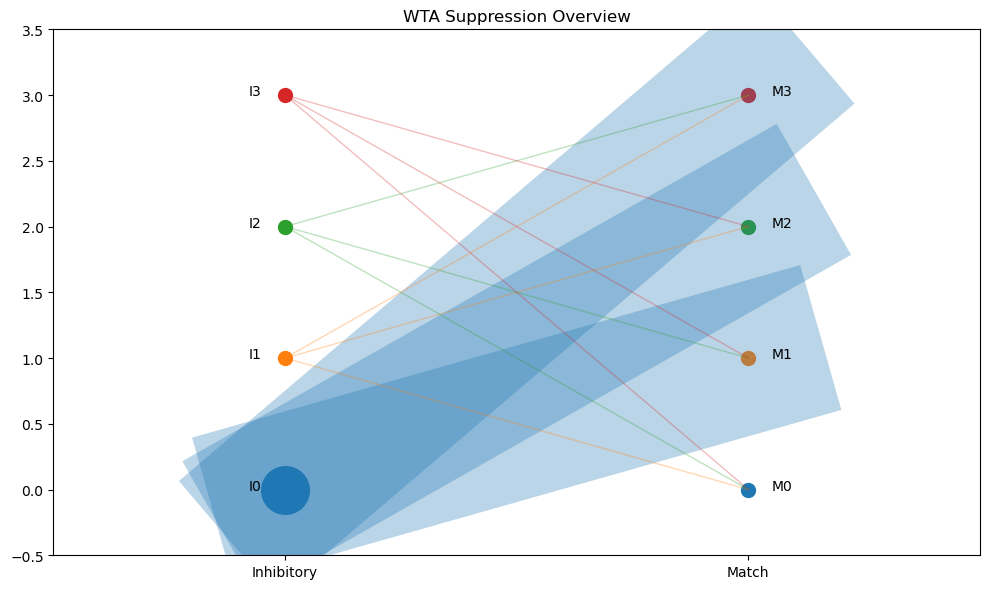

In [26]:
##############################################################################
# SUPPRESSION DEBUG VIEW
#
# Left  = inhibitory population activity
# Right = match population activity
#
# Same color = same channel
#
##############################################################################

fig, ax = plt.subplots(
    figsize=(10,6)
)

for ch in range(N_CH):

    inh_strength = inh_scores[ch]
    match_strength = match_scores[ch]

    # inhibitory node
    ax.scatter(
        0,
        ch,
        s=100 + inh_strength * 10,
        color=COLORS[ch]
    )

    # match node
    ax.scatter(
        1,
        ch,
        s=100 + match_strength * 10,
        color=COLORS[ch]
    )

    ax.text(
        -0.05,
        ch,
        f"I{ch}",
        ha="right"
    )

    ax.text(
        1.05,
        ch,
        f"M{ch}",
        ha="left"
    )

##############################################################################
# DRAW SUPPRESSION CONNECTIONS
##############################################################################

for src in range(N_CH):

    for dst in range(N_CH):

        if src == dst:
            continue

        strength = inh_scores[src]

        ax.plot(
            [0,1],
            [src,dst],
            color=COLORS[src],
            alpha=0.3,
            linewidth=1 + strength
        )

ax.set_xlim(-0.5,1.5)
ax.set_ylim(-0.5,N_CH-0.5)

ax.set_xticks([0,1])
ax.set_xticklabels([
    "Inhibitory",
    "Match"
])

ax.set_title(
    "WTA Suppression Overview"
)

plt.tight_layout()
plt.show()

### Since this is working(Llookslike), we build an slider for attribute tunning:

In [27]:
def run_experiment(
    ampa_tau,
    gaba_tau,
    threshold,
    leak
):

    param_group["AMPA_TAU"] = ampa_tau
    param_group["GABA_TAU"] = gaba_tau
    param_group["THRESHOLD"] = threshold
    param_group["LEAK"] = leak

    set_params(
        model,
        param_group=param_group
    )

    # run network

    # plot scores

In [28]:
from ipywidgets import interact

print(param_group)

dynapse1::Dynapse1ParameterGroup param_map={ { IF_AHTAU_N :  } { IF_AHTHR_N :  } { IF_AHW_P :  } { IF_BUF_P :  } { IF_CASC_N :  } { IF_DC_P :  } { IF_NMDA_N :  } { IF_RFR_N :  } { IF_TAU1_N :  } { IF_TAU2_N :  } { IF_THR_N :  } { NPDPIE_TAU_F_P :  } { NPDPIE_TAU_S_P :  } { NPDPIE_THR_F_P :  } { NPDPIE_THR_S_P :  } { NPDPII_TAU_F_P :  } { NPDPII_TAU_S_P :  } { NPDPII_THR_F_P :  } { NPDPII_THR_S_P :  } { PS_WEIGHT_EXC_F_N :  } { PS_WEIGHT_EXC_S_N :  } { PS_WEIGHT_INH_F_N :  } { PS_WEIGHT_INH_S_N :  } { PULSE_PWLK_P :  } { R2R_P :  } }, core_id=0, chip_id=0.


In [29]:
from ipywidgets import interact

def tune_network(

    gaba_b_weight,
    gaba_a_weight,

    nmda_tau,
    ampa_tau,

    gaba_b_tau,
    gaba_a_tau

):

    ##################################################################
    # GABA B
    ##################################################################

    param_group.param_map[
        "PS_WEIGHT_INH_S_N"
    ].fine_value = gaba_b_weight

    ##################################################################
    # GABA A
    ##################################################################

    param_group.param_map[
        "PS_WEIGHT_INH_F_N"
    ].fine_value = gaba_a_weight

    ##################################################################
    # NMDA
    ##################################################################

    param_group.param_map[
        "NPDPIE_TAU_S_P"
    ].fine_value = nmda_tau

    ##################################################################
    # AMPA
    ##################################################################

    param_group.param_map[
        "NPDPIE_TAU_F_P"
    ].fine_value = ampa_tau

    ##################################################################
    # INH FAST
    ##################################################################

    param_group.param_map["NPDPII_TAU_F_P" ].fine_value = gaba_a_tau

    ##################################################################
    # INH SLO
    param_group.param_map["NPDPII_TAU_S_P"].fine_value = gaba_b_tau

#APPLY##################################################################
    set_params(
        model,
        param_group=param_group
    )

    print("\nCurrent Parameters\n")
    print(f"GABA_B_WEIGHT : {gaba_b_weight}")
    print(f"GABA_A_WEIGHT : {gaba_a_weight}")
    print(f"NMDA_TAU      : {nmda_tau}")
    print(f"AMPA_TAU      : {ampa_tau}")
    print(f"GABA_B_TAU    : {gaba_b_tau}")
    print(f"GABA_A_TAU    : {gaba_a_tau}")

In [30]:
interact(

    tune_network,

    gaba_b_weight=(0,255,1),
    gaba_a_weight=(0,255,1),

    nmda_tau=(0,255,1),
    ampa_tau=(0,255,1),

    gaba_b_tau=(0,255,1),
    gaba_a_tau=(0,255,1)

)

interactive(children=(IntSlider(value=127, description='gaba_b_weight', max=255), IntSlider(value=127, descrip…

<function __main__.tune_network(gaba_b_weight, gaba_a_weight, nmda_tau, ampa_tau, gaba_b_tau, gaba_a_tau)>

In [93]:
for fine in [80,120,160,200,240]:

    param_group.param_map[
        'PS_WEIGHT_EXC_F_N'
    ].fine_value = fine

    set_params(
        model,
        param_group
    )

    run_experiment()

    print(
        fine,
        match_scores
    )

NameError: name 'run_experiment' is not defined

In [ ]:
get_bias("PS_WEIGHT_EXC_F_N")

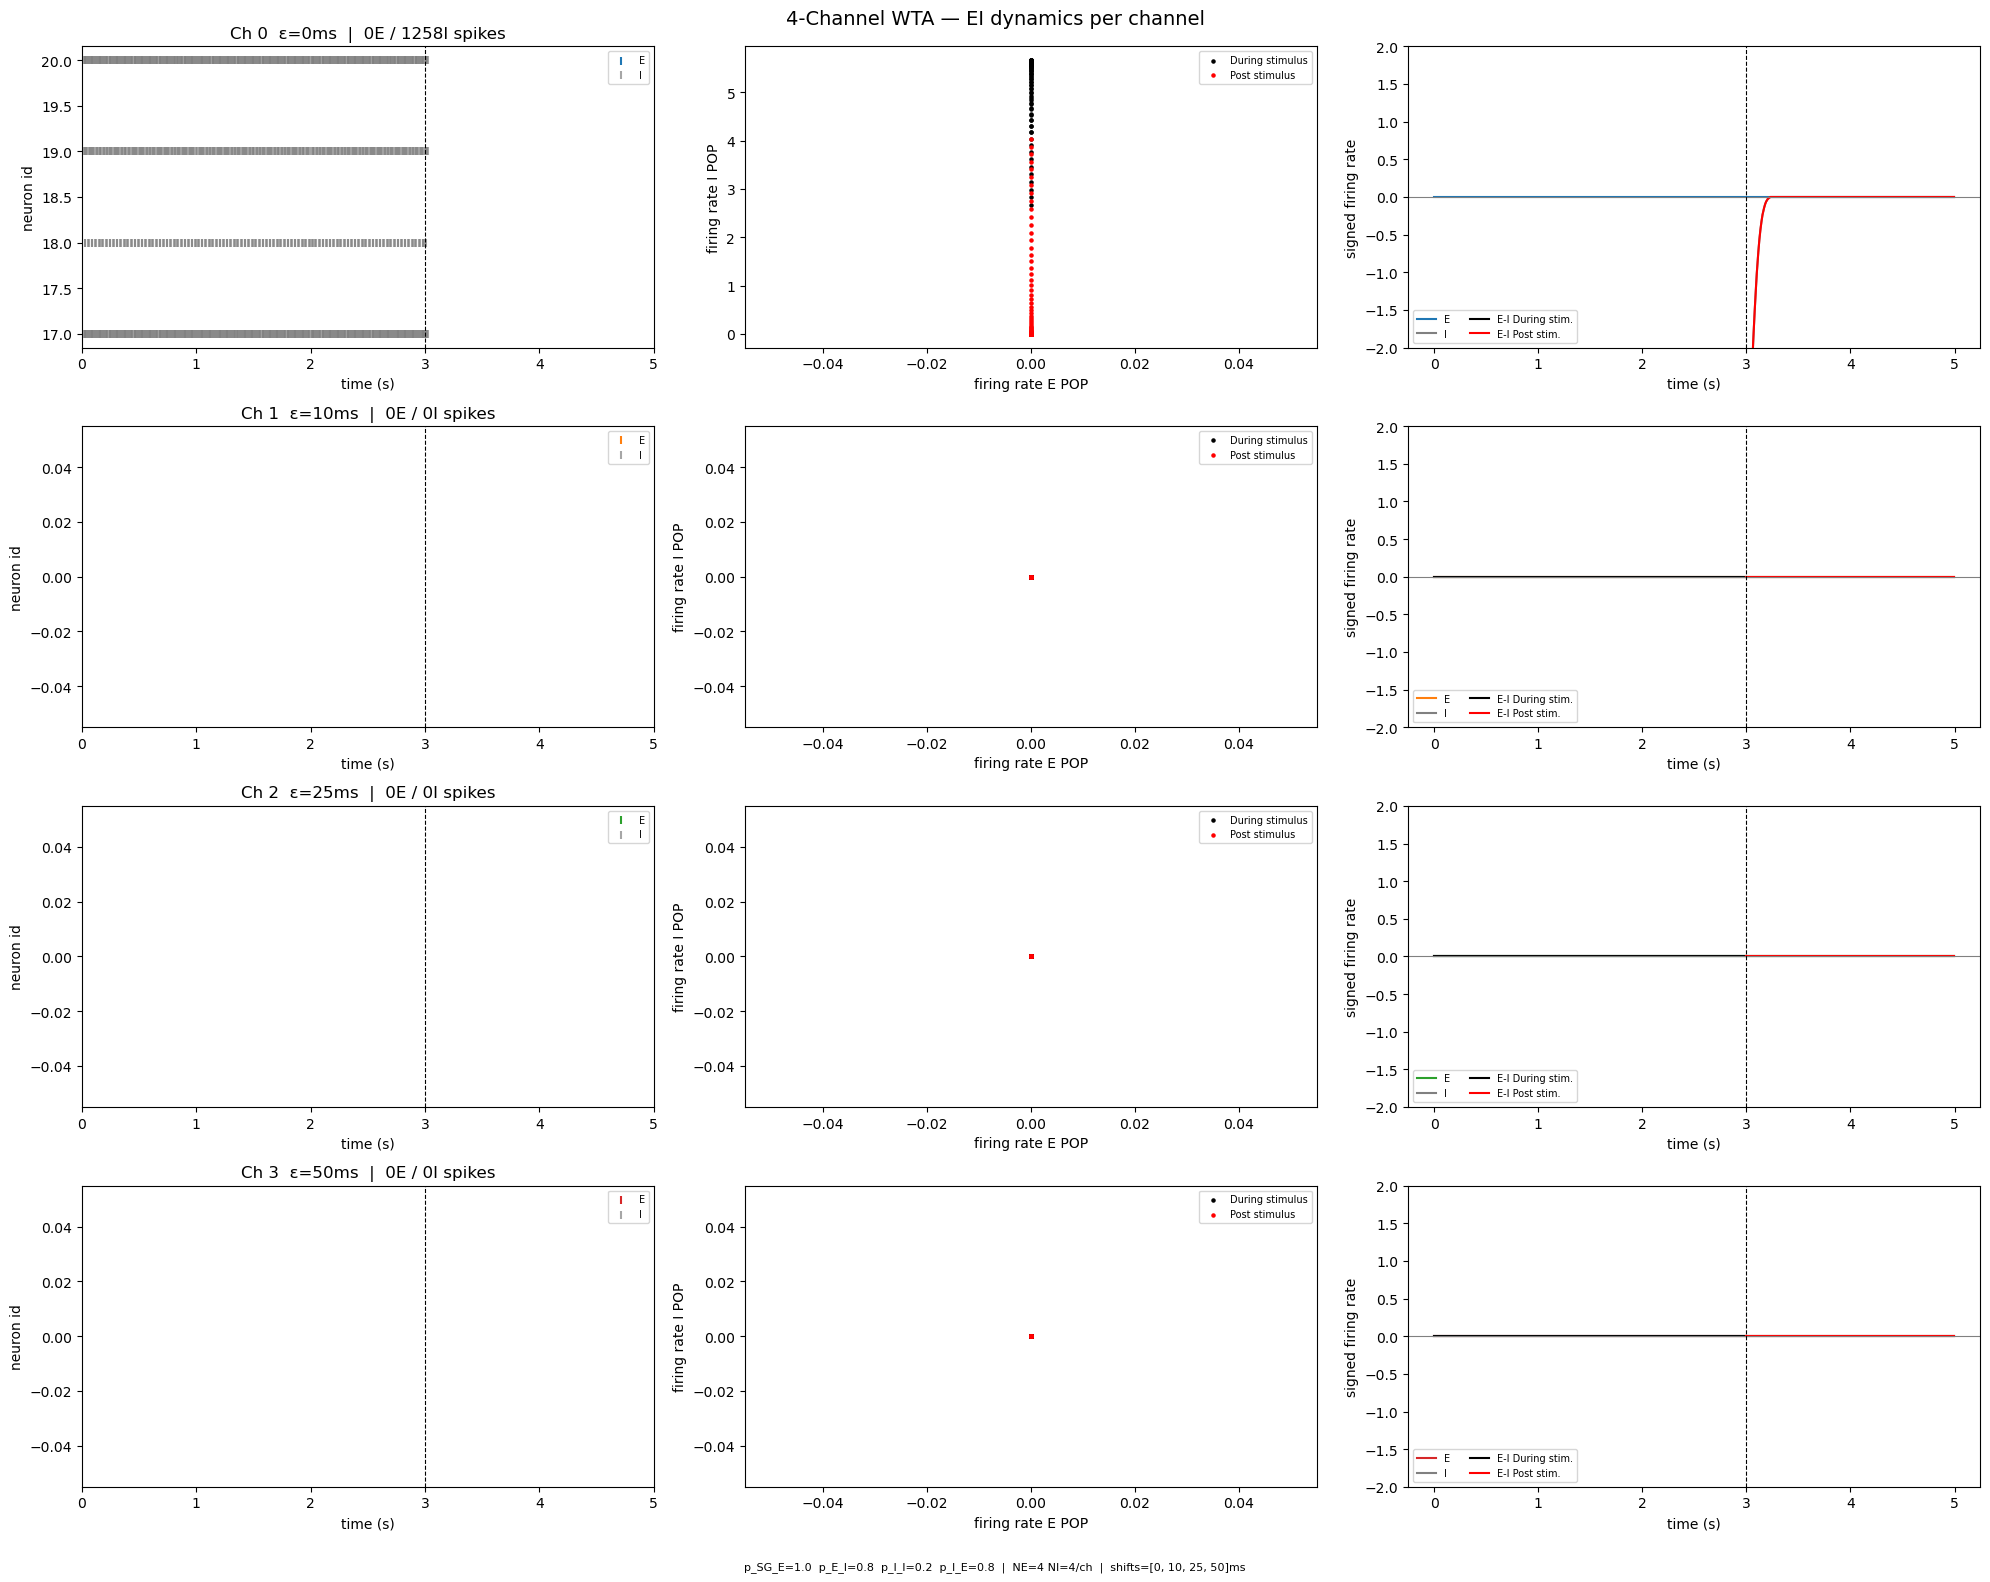

Saved: step3_wta_result.png


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# 9. PLOT  — 4 rows (channels) × 3 cols (raster | phase | signed rate)
#            exactly like the tutorial EI_balance plot
# ─────────────────────────────────────────────────────────────────────────────

NN   = 256   # neurons per core on DynapseSE1
fs   = 200
D    = D_stim + D_post

# global spike id  (core * NN + neuron_id)  — same trick as tutorial
spike_id = spike_core * NN + spike_nrn

# Gaussian kernel (same as tutorial)
sigma = 0.01
x     = np.arange(int(-0.2 * fs), int(0.2 * fs)) / fs
gauss = np.exp(-x**2 / sigma)

# global ID ranges per channel
#   core 0, E: ch0→1-4, ch1→5-8, ch2→9-12, ch3→13-16
#   core 0, I: ch0→17-20, ch1→21-24, ch2→25-28, ch3→29-32
def g_range(ch):
    e_lo = 0*NN + 1  + ch * NE_CH      # global
    e_hi = e_lo + NE_CH
    i_lo = 0*NN + 17 + ch * NI_CH
    i_hi = i_lo + NI_CH
    return e_lo, e_hi, i_lo, i_hi

COLORS     = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
stim_bins  = int(D_stim * fs)
post_bins  = int(D_post  * fs)
t_stim_ax  = np.arange(stim_bins) / fs
t_post_ax  = np.arange(post_bins) / fs + D_stim
t_all_ax   = np.arange(int(D * fs)) / fs

fig, axes = plt.subplots(N_CH, 3, figsize=(20, 4 * N_CH))
fig.suptitle("4-Channel WTA — EI dynamics per channel", fontsize=14)

for ch in range(N_CH):
    e_lo, e_hi, i_lo, i_hi = g_range(ch)

    mask_E = (spike_id >= e_lo) & (spike_id < e_hi)
    mask_I = (spike_id >= i_lo) & (spike_id < i_hi)

    t_E  = spike_t[mask_E];  id_E = spike_id[mask_E]
    t_I  = spike_t[mask_I];  id_I = spike_id[mask_I]

    # binned population activity
    binPOP = np.zeros((2, int(D * fs)))
    for t in t_E:
        if 0 <= t < D:
            binPOP[0, int(t * fs)] = 1
    for t in t_I:
        if 0 <= t < D:
            binPOP[1, int(t * fs)] = 1

    binPOP[0] = np.convolve(binPOP[0], gauss, 'same')
    binPOP[1] = np.convolve(binPOP[1], gauss, 'same')

    ax1, ax2, ax3 = axes[ch]

    # ── raster ───────────────────────────────────────────────────────────
    ax1.scatter(t_E, id_E, marker='|', s=40, color=COLORS[ch], label='E')
    ax1.scatter(t_I, id_I, marker='|', s=40, color='gray',     label='I', alpha=0.7)
    ax1.axvline(D_stim, color='k', lw=0.8, ls='--')
    ax1.set_xlabel('time (s)')
    ax1.set_ylabel('neuron id')
    ax1.set_xlim(0, D)
    ax1.set_title(f"Ch {ch}  ε={J_SHIFT_PARAM[ch]}ms  |  {mask_E.sum()}E / {mask_I.sum()}I spikes")
    ax1.legend(fontsize=7)

    # ── phase portrait ───────────────────────────────────────────────────
    ax2.scatter(binPOP[0, :stim_bins] / NE_CH,
                binPOP[1, :stim_bins] / NI_CH,
                c='k', s=5, label='During stimulus')
    ax2.scatter(binPOP[0, stim_bins:] / NE_CH,
                binPOP[1, stim_bins:] / NI_CH,
                c='red', s=5, label='Post stimulus')
    ax2.set_xlabel('firing rate E POP')
    ax2.set_ylabel('firing rate I POP')
    ax2.legend(fontsize=7)

    # ── signed firing rate ───────────────────────────────────────────────
    ax3.plot(t_all_ax,  binPOP[0] / NE_CH, color=COLORS[ch], label='E')
    ax3.plot(t_all_ax, -binPOP[1] / NI_CH, color='gray',     label='I')
    ax3.plot(t_stim_ax,
             binPOP[0, :stim_bins] / NE_CH - binPOP[1, :stim_bins] / NI_CH,
             c='k', label='E-I During stim.')
    ax3.plot(t_post_ax,
             binPOP[0, stim_bins:] / NE_CH - binPOP[1, stim_bins:] / NI_CH,
             c='red', label='E-I Post stim.')
    ax3.axhline(0, color='gray', lw=0.8)
    ax3.axvline(D_stim, color='k', lw=0.8, ls='--')
    ax3.set_xlabel('time (s)')
    ax3.set_ylabel('signed firing rate')
    ax3.set_ylim(-2, 2)
    ax3.legend(loc='lower left', ncol=2, fontsize=7)

plt.figtext(
    0.5, 0.005,
    f"p_SG_E={p_SG_E}  p_E_I={p_E_I}  p_I_I={p_I_I}  p_I_E={p_I_E}  |  "
    f"NE={NE_CH} NI={NI_CH}/ch  |  shifts={J_SHIFT_PARAM}ms",
    ha='center', fontsize=8
)
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig("keyspot_plots\step3_wta_result.png", dpi=150)
plt.show()
print("Saved: step3_wta_result.png")

In [10]:
# print AMPA weight values

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value))

Linear: 752941184.0
Coarse: 7
Fine: 80


In [8]:
param_group = config1.chips[0].cores[0].parameter_group 

In [9]:
# set AMPA (fast excitatory) weight 

param_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value = 160
param_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 4


In [10]:
# print AMPA (fast excitatory) weight values

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value))

Linear: 3137255.0
Coarse: 4
Fine: 160


In [11]:
# set NMDA (slow excitatory) weight

param_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value = 180
param_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 4

# param_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value = 0
# param_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 0

In [12]:
# print NMDA (slow excitatory) weight

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value))

Linear: 3529412.0
Coarse: 4
Fine: 180


In [13]:
# set GABA B (slow inhibitory) weight

param_group.param_map['PS_WEIGHT_INH_S_N'].fine_value = 150
param_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 4

In [14]:
# print GABA B (slow inhibitory) weight

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].fine_value))

Linear: 2941177.0
Coarse: 4
Fine: 150


In [15]:
# set GABA A (fast inhibitory) weight

param_group.param_map['PS_WEIGHT_INH_F_N'].fine_value = 200
param_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 4

In [100]:
# print GABA A (fast inhibitory) weight

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].fine_value))

Linear: 0.0
Coarse: 0
Fine: 0


In [101]:
# set NMDA (slow exc) tau 
# remember the higher the tau param, the higher the leak, the faster the decay

param_group.param_map['NPDPIE_TAU_S_P'].fine_value = 10
param_group.param_map['NPDPIE_TAU_S_P'].coarse_value = 4

In [102]:
# print NMDA (slow exc) tau 

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_S_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].fine_value))

Linear: 196275.0
Coarse: 4
Fine: 10


In [103]:
# # set AMPA (fast exc) tau 

param_group.param_map['NPDPIE_TAU_F_P'].fine_value = 10
param_group.param_map['NPDPIE_TAU_F_P'].coarse_value = 4

In [104]:
# print AMPA (fast exc) tau 

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_F_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].fine_value))

Linear: 196275.0
Coarse: 4
Fine: 10


In [105]:
param_group.param_map["NPDPII_TAU_F_P"].coarse_value = 4
param_group.param_map["NPDPII_TAU_F_P"].fine_value = 8

param_group.param_map["NPDPII_TAU_S_P"].coarse_value = 4
param_group.param_map["NPDPII_TAU_S_P"].fine_value = 8

In [106]:
#config1 = model.get_configuration() 

### checl range of params 
param = config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P']
print(param)
dir(param)
type(param.coarse_value)
print(param.coarse_value)

dynapse1::Dynapse1Parameter param_name=NPDPIE_TAU_S_P, coarse_value=4, fine_value=10, type=P.
4


241 NMDA synapses
New configuration applied to DYNAP-SE1!
monitored neurons: [(0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 0, 4), (0, 0, 5), (0, 0, 6), (0, 0, 7), (0, 0, 8), (0, 0, 9), (0, 0, 10), (0, 0, 11), (0, 0, 12), (0, 0, 13), (0, 0, 14), (0, 0, 15), (0, 0, 16), (0, 0, 17), (0, 0, 18), (0, 0, 19), (0, 0, 20), (0, 0, 21), (0, 0, 22), (0, 0, 23), (0, 0, 24), (0, 0, 25), (0, 0, 26), (0, 0, 27), (0, 0, 28), (0, 0, 29), (0, 0, 30), (0, 0, 31), (0, 0, 32), (0, 0, 33), (0, 0, 34), (0, 0, 35), (0, 0, 36), (0, 0, 37), (0, 0, 38), (0, 0, 39), (0, 0, 41), (0, 0, 42), (0, 0, 43), (0, 0, 44), (0, 0, 45), (0, 0, 46), (0, 0, 47), (0, 0, 48), (0, 0, 49), (0, 0, 50), (0, 0, 51), (0, 0, 52), (0, 0, 53), (0, 0, 54), (0, 0, 55), (0, 0, 56), (0, 0, 57), (0, 0, 58), (0, 0, 59), (0, 0, 60), (0, 0, 61), (0, 0, 62), (0, 0, 63), (0, 0, 64), (0, 0, 65), (0, 0, 66), (0, 0, 67), (0, 0, 68), (0, 0, 69), (0, 0, 70), (0, 0, 71), (0, 0, 72), (0, 0, 73), (0, 0, 74), (0, 0, 75), (0, 0, 76), (0, 0, 77), (0, 0, 78), (0, 0, 

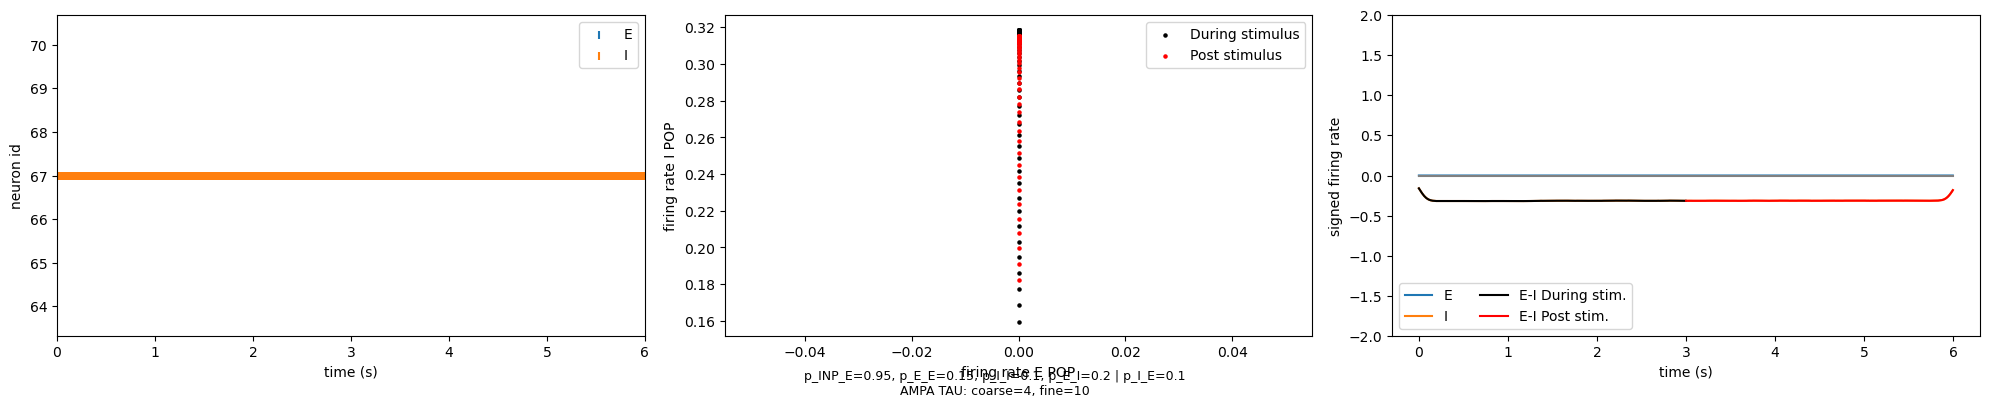

In [107]:
#import importlib # Module to dynamically reload modules
#importlib.reload(params) # Reloads the params module to ensure any changes are recognized

###what does this actually do ? 
model.update_parameter_group(param_group, 0, 0) # update params based on the params you changed 

p_INP_E = 0.95       # Probability of connections from spike generator to excitatory population
p_E_E   = 0.15        # Probability of connections among excitatory neurons
p_I_I   = 0.1           # Probability of connections among inhibitory neurons
p_E_I   = 0.2      # Probability of connections from excitatory to inhibitory
p_I_E   = 0.1          # Probability of connections from inhibitory to excitatory

# p_INP_E = .7            # Probability of connections from spike generator to excitatory population
# p_E_E   = 0.1          # Probability of connections among excitatory neurons
# p_I_I   = 0.5             # Probability of connections among inhibitory neurons
# p_E_I   = 0.2           # Probability of connections from excitatory to inhibitory
# p_I_E   = 0.5 

#### Given 

#model.update_parameter_group(param_group, 0, 0) # update params based on the params you changed 

# p_INP_E = 1             # Probability of connections from spike generator to excitatory population
# p_E_E   = 0.8             # Probability of connections among excitatory neurons
# p_I_I   = 0.0             # Probability of connections among inhibitory neurons
# p_E_I   = 0.5             # Probability of connections from excitatory to inhibitory
# p_I_E   = 0.0             # Probability of connections from inhibitory to excitatory

# We use CHIP 0 in this exercise 
    # remember, there are 4 chips per every blue box. There are 4 cores per every chip. There are 256 neurons per every core.
    
# We are using a SPIKEGEN located  in CORE 1. POPULATION E is in CORE 0. POPULATION I is in CORE 0.
    # when you set up your own EI balanced networks in the future, we advise that you keep the POPULATION E and POPULATION I in different cores to more easily control the parameters

# Create a NetworkGenerator object to build the network configuration:
net_gen = NetworkGenerator()
net_gen.clear_network() # Clear any existing network structure

# We will create a spike generator in chip=0, core=1, neuron=1

spikegen_ids = [(0, 1, 1)]
spikegens = []
for spikegen_id in spikegen_ids:
    spikegens.append(Neuron(spikegen_id[0],spikegen_id[1],spikegen_id[2],True))
## YOYO accumulkates the spikes in given frequency and precise timing sending to the location of spike:ids @ the chip 




# Define the size of the excitatory population and create their neuron IDs:
NE    = 40
E_ids = [(0,0,ni) for ni in range(1,NE)]
neurons_E = []
for nid in E_ids:
    neurons_E.append(Neuron(nid[0],nid[1],nid[2]))


# Define the size of the inhibitory population and create their neuron IDs
NI    = 40
I_ids = [(0,0,ni+NE) for ni in range(1,NI)]
neurons_I = []
for nid in I_ids:
    neurons_I.append(Neuron(nid[0],nid[1],nid[2]))


# connect SPIKEGEN to POPULATION E:
for i in range(int(NE*p_INP_E)-1):
    # Here, we connect from spikegens[0] to neurons_E[i]
    # using the AMPA synapse type
    net_gen.add_connection(spikegens[0], neurons_E[i], dyn1.Dynapse1SynType.AMPA)

# connect POPULATION E to POPULATION E
    # (Connect excitatory neurons among themselves (E to E) with probability p_E_E)
counter=0
for i in range(NE-1):
    for j in range(NE-1):
        if(i!=j and p_E_E > np.random.uniform()):
            counter+=1
            # Use NMDA synapse type for these connections. So you can tune the parameters of the NMDA and AMPA synapses separately
            net_gen.add_connection(neurons_E[i], neurons_E[j], dyn1.Dynapse1SynType.NMDA)
print(str(counter)+" NMDA synapses")
            
# connect POPULATION E to POPULATION I
for i in range(NE-1):
    for j in range(NI-1):
        if(p_E_I > np.random.uniform()):
            net_gen.add_connection(neurons_E[i], neurons_I[j], dyn1.Dynapse1SynType.AMPA)


# connect POPULATION I to POPULATION I 
for i in range(NI-1):
    for j in range(NI-1):
        if(i!=j and p_I_I > np.random.uniform()):
            net_gen.add_connection(neurons_I[i], neurons_I[j], dyn1.Dynapse1SynType.GABA_A)


# connect POPULATION I to POPULATION E
for i in range(NI-1):
    for j in range(NE-1):
        if(p_I_E > np.random.uniform()):
            net_gen.add_connection(neurons_I[i], neurons_E[j], dyn1.Dynapse1SynType.GABA_B)

# make a dynapse1config using the network
new_config = net_gen.make_dynapse1_configuration()

# apply the configuration
model.apply_configuration(new_config)


for rate in [50]:
    D_stim = 3 # stimulus duration (s)
    D_post_stim = 3 # post stimulus duration (s)
    D = D_stim + D_post_stim
    global_poisson_gen_ids = ut.get_global_id_list(spikegen_ids)
    poisson_gen = model.get_poisson_gen()
    poisson_gen.set_chip_id(0)
    poisson_gen.write_poisson_rate_hz(global_poisson_gen_ids[0], rate)
    
    # set parameters
### turned of 
    #set_params(model)#, param_group = param_group) # note here: set_params(model) will revert the params back to the standard params
### newly setted for changing behavior
    set_params(model, param_group = param_group)
    # if you want to use new parameters that you set via this script, you need to use set_params(model, param_group = param_group)
    
    
    # how to get events of selected neurons
    monitored_neurons = E_ids + I_ids
    graph, filter_node, sink_node = ut.create_neuron_select_graph(model, monitored_neurons)

### create graphs have to be stopped____________________________________________
    graph.start()

    # start the poisson gen
    poisson_gen.start()

    # select the neurons to monitor
    print("monitored neurons:", monitored_neurons)
    filter_node.set_neurons(monitored_neurons)

    # clear the buffer
    sink_node.get_events()

    api.reset_timestamp()
    time.sleep(D_stim)

    poisson_gen.stop()
    time.sleep(D_post_stim)
    graph.stop()
    events = sink_node.get_events()
    
### create graphs have to be stopped____________________________________________

    # process the events
    print(len(events),"events.")

    NN = 256 # neurons in 1 core
    spike_id = []
    spike_t  = []
    for evt in events:
        spike_id.append(evt.core_id*NN + evt.neuron_id)
        spike_t.append(evt.timestamp*1e-6)
    spike_id = np.array(spike_id)
    spike_t  = np.array(spike_t) 

    # E mean firing rate
    fs = 200
    binPOP = np.zeros((2,int(D*fs)))
    for i in range(len(events)):
        if(spike_t[i]<D):
            binPOP[spike_id[i]//NE,int(spike_t[i]*fs)]=1

    sigma = 0.01
    x = np.arange(int(-0.2*fs),int(0.2*fs))/fs
    gauss = np.exp(-x**2/sigma)

    binPOP[0] = np.convolve(binPOP[0],gauss,'same')
    binPOP[1] = np.convolve(binPOP[1],gauss,'same')

    f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,4))

    ax1.scatter(spike_t[spike_id<(NE)],spike_id[spike_id<(NE)],marker='|',label='E')
    ax1.scatter(spike_t[spike_id>(NE)],spike_id[spike_id>(NE)],marker='|',label='I')
    ax1.set_xlabel('time (s)')
    ax1.set_ylabel('neuron id')
    ax1.legend()
    ax1.set_xlim(0,D)


    ax2.scatter(binPOP[0,:int(D_stim*fs)]/NE,binPOP[1,:int(D_stim*fs)]/NI,c='k',s=5,label='During stimulus')
    ax2.scatter(binPOP[0,int(D_stim*fs):]/NE,binPOP[1,int(D_stim*fs):]/NI,c='red',s=5,label='Post stimulus')
    ax2.set_ylabel('firing rate I POP')
    ax2.set_xlabel('firing rate E POP')
    ax2.legend()

    ax3.plot(np.arange(int(D*fs))/fs,binPOP[0]/NE,label='E')
    ax3.plot(np.arange(int(D*fs))/fs,-binPOP[1]/NI,label='I')
    ax3.plot(np.arange(int(D_stim*fs))/fs,binPOP[0,:int(D_stim*fs)]/NE-binPOP[1,:int(D_stim*fs)]/NI,c='k',label='E-I During stim.')
    ax3.plot(np.arange(int(D_post_stim*fs))/fs+int(D_stim*fs)/fs,binPOP[0,int(D_stim*fs):]/NE-binPOP[1,int(D_stim*fs):]/NI,c='red',label='E-I Post stim.')
    ax3.plot([0,D],[0,0],'gray')
    ax3.set_ylabel('signed firing rate')
    ax3.set_xlabel('time (s)')
    ax3.legend(loc='lower left', ncol=2)
    ax3.set_ylim(-2,2)

###write param to pic

    param = param_group.param_map['NPDPIE_TAU_F_P']

    plt.subplots_adjust(bottom=0.1)
    plt.figtext(0.5, 0.001, f"p_INP_E={p_INP_E}, p_E_E={p_E_E}, p_I_I={p_I_I}, p_E_I={p_E_I} | p_I_E={p_I_E}\n"     f"AMPA TAU: coarse={param.coarse_value}, fine={param.fine_value}",ha="center", fontsize=9)

    plt.tight_layout()
    #plt.savefig('EI.png')
    #plt.savefig(f"./plots/NMDA_syn_{counter}_{p_INP_E}_plt.png")
    plt.show()

Can you achieve something similar as the below figure?

In [108]:
Image("../lab5/EI_balance.png")

FileNotFoundError: No such file or directory: '../lab5/EI_balance.png'

FileNotFoundError: No such file or directory: '../lab5/EI_balance.png'

<IPython.core.display.Image object>